In [2]:
import scipy.io as sio
import numpy as np
from scipy.signal import butter, filtfilt

In [3]:
def bandpass_filter(data, lowcut=8, highcut=30, fs=250, order=4):
    """Applies a Butterworth bandpass filter to EEG data."""
    nyquist = 0.5 * fs  # Nyquist frequency
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data, axis=-1)

In [4]:
def load_BCI2a_data(data_path, subject, training, all_trials=True):    
    # Define MI-trials parameters
    n_channels = 22
    n_tests = 6 * 48     
    window_Length = 7 * 250  # Total trial duration (7s)

    # Define MI trial window 
    fs = 250          # Sampling rate
    t1 = int(2 * fs)  # Start time_point (2s)
    t2 = int(6 * fs)  # End time_point (6s)

    class_return = np.zeros(n_tests)
    data_return = np.zeros((n_tests, n_channels, window_Length))  #(trials x channels x time)

    NO_valid_trial = 0
    if training:
        a = sio.loadmat(data_path + 'A0' + str(subject + 1) + 'T.mat')   #()
    else:
        a = sio.loadmat(data_path + 'A0' + str(subject + 1) + 'E.mat')

    a_data = a['data']  #()
    
    for ii in range(a_data.size):
        a_data1 = a_data[0, ii]
        a_data2 = [a_data1[0, 0]]
        a_data3 = a_data2[0]
        a_X = a_data3[0]  # EEG signals
        a_trial = a_data3[1]  # Trial start indices
        a_y = a_data3[2]  # Class labels
        a_artifacts = a_data3[5]  # Artifact presence

        for trial in range(a_trial.size):
            if a_artifacts[trial] != 0 and not all_trials:
                continue
            # Extract EEG trial (time x channels) and transpose to (channels x time)
            trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
            
            # Apply bandpass filter
            trial_data = bandpass_filter(trial_data, lowcut=8, highcut=30, fs=fs, order=4)

            data_return[NO_valid_trial, :, :] = trial_data
            class_return[NO_valid_trial] = int(a_y[trial])
            NO_valid_trial += 1        

    # Keep only valid trials and select MI window (2s to 6s)
    data_return = data_return[0:NO_valid_trial, :, t1:t2]
    class_return = class_return[0:NO_valid_trial]
    class_return = (class_return - 1).astype(int)  # Convert to zero-based index

    return data_return, class_return

In [26]:
train_data.shape, train_label.shape, test_data.shape, test_label.shape

((262, 22, 1000), (262,), (228, 22, 1000), (228,))

In [5]:
from numpy.lib.stride_tricks import sliding_window_view
import math

def hjorth_parameters(signal):
    first_deriv = np.diff(signal)
    second_deriv = np.diff(first_deriv)
    
    activity = np.var(signal)
    mobility = np.sqrt(np.var(first_deriv) / activity) if activity != 0 else 0
    complexity = (np.sqrt(np.var(second_deriv) / np.var(first_deriv)) 
                  if np.var(first_deriv) != 0 else 0)
    return activity, mobility, complexity

def higuchi_fd(signal, kmax=5):
    N = len(signal)
    L = []
    for k in range(1, kmax + 1):
        Lk = 0
        for m in range(k):
            idx = np.arange(1, int(np.floor((N - m) / k)), dtype=int)
            Lm = np.sum(np.abs(signal[m + idx * k] - signal[m + (idx - 1) * k]))
            Lm = (Lm * (N - 1)) / (len(idx) * k)
            Lk += Lm
        L.append(Lk / k)
    logL = np.log(L)
    logk = np.log(1.0 / np.arange(1, kmax + 1))
    return np.polyfit(logk, logL, 1)[0]  # slope is the FD

def sample_entropy(signal, m=2, r=0.2):
    N = len(signal)
    r *= np.std(signal)
    def _phi(m):
        x = sliding_window_view(signal, window_shape=m)
        C = np.sum([np.sum(np.abs(x - xi).max(axis=1) <= r) - 1 for xi in x])
        return C
    try:
        return -np.log(_phi(m + 1) / _phi(m))
    except:
        return 0.0  # if division by zero

In [5]:
import numpy as np
from scipy.stats import skew, kurtosis
from scipy.signal import welch
from scipy.linalg import eigh

def extract_features(data, labels, fs=250, n_csp_components=2):
    """
    Extracts time-domain, frequency-domain (per channel), and CSP (global) features.
    
    Output:
        features: numpy array of shape (trials, channels, num_features)
        csp_features: numpy array of shape (trials, csp_feature_dim)
    """
    n_trials, n_channels, n_times = data.shape
    per_channel_features = []

    # ---- CSP Filters (global features) ----
    csp_filters = []
    classes = np.unique(labels)
    
    for c in classes:
        X1 = data[labels == c]
        X2 = data[labels != c]

        cov1 = np.mean([np.cov(trial) for trial in X1], axis=0)
        cov2 = np.mean([np.cov(trial) for trial in X2], axis=0)
        cov_total = cov1 + cov2

        eigvals, eigvecs = eigh(cov1, cov_total)
        sorted_indices = np.argsort(eigvals)[::-1]
        eigvecs = eigvecs[:, sorted_indices]

        # Top & bottom CSP filters
        filters = np.hstack((eigvecs[:, :n_csp_components], eigvecs[:, -n_csp_components:]))
        csp_filters.append(filters)

    # ---- Feature Extraction ----
    csp_feature_list = []

    for trial in range(n_trials):
        trial_feature_channels = []

        # Per-channel features
        for ch in range(n_channels):
            signal = data[trial, ch, :]

            # Time-domain features
            peak_amp = np.max(np.abs(signal))
            latency = np.argmax(np.abs(signal)) / fs
            auc = np.trapz(np.abs(signal), dx=1/fs)
            slope = (signal[-1] - signal[0]) / n_times
            ptp_amp = np.ptp(signal)
            mean_abs_amp = np.mean(np.abs(signal))
            rms_amp = np.sqrt(np.mean(signal**2))
            std_dev = np.std(signal)
            skewness = skew(signal)
            kurt_val = kurtosis(signal)
            zork = ((signal[:-1] * signal[1:]) < 0).sum()

            # Frequency-domain features
            freqs, psd = welch(signal, fs=fs, nperseg=fs)
            mean_power = np.mean(psd)
            var_power = np.var(psd)
            skew_power = skew(psd)
            kurt_power = kurtosis(psd)
            max_power = np.max(psd)
            psd_norm = psd / np.sum(psd)
            spectral_entropy = -np.sum(psd_norm * np.log2(psd_norm + 1e-12))

            channel_features = [
                peak_amp, latency, auc, slope, ptp_amp, mean_abs_amp, rms_amp,
                std_dev, skewness, kurt_val, zork,
                mean_power, var_power, skew_power, kurt_power, max_power, spectral_entropy
            ]

            trial_feature_channels.append(channel_features)

        # Add per-channel features to list
        per_channel_features.append(trial_feature_channels)

        # CSP features (global)
        trial_csp_feats = []
        for filters in csp_filters:
            projected = filters.T @ data[trial]
            variances = np.var(projected, axis=1)
            log_var = np.log(variances + 1e-10)
            trial_csp_feats.extend(log_var)
        csp_feature_list.append(trial_csp_feats)

    # Final output shapes
    return np.array(per_channel_features), np.array(csp_feature_list)

In [150]:
import numpy as np
from scipy.linalg import eigh

def compute_csp_filters(data, labels, n_classes=4, m=3):
    n_trials, n_channels, n_times = data.shape
    covs = np.array([trial @ trial.T / np.trace(trial @ trial.T) for trial in data])
    class_covs = [np.mean(covs[labels == c], axis=0) for c in range(n_classes)]
    
    filters = []
    for c in range(n_classes):
        C_c = class_covs[c]
        C_rest = np.sum([class_covs[j] for j in range(n_classes) if j != c], axis=0)
        evals, evecs = eigh(C_c, C_rest + 1e-6 * np.eye(n_channels))
        filters.append(evecs[:, :m].T)
    
    return np.concatenate(filters, axis=0)  # (n_components, n_channels)
def per_channel_csp_features(data, csp_filters):
    n_components, n_channels = csp_filters.shape
    n_trials, _, n_times = data.shape
    
    # Project data using CSP filters
    projected = np.zeros((n_trials, n_components, n_times))
    for i in range(n_trials):
        projected[i] = csp_filters @ data[i]  # (n_components, n_times)
    
    # Compute log-variance per channel contribution
    features = np.zeros((n_trials, n_channels, n_components))
    for ch in range(n_channels):
        # Weight each CSP component by the channel's contribution to the filter
        weights = csp_filters[:, ch]  # (n_components,)
        
        # Reshape weights to (1, n_components, 1) for broadcasting
        weighted_proj = projected * weights[np.newaxis, :, np.newaxis]  # Correct shape
        
        # Compute variance over time (axis=2)
        weighted_var = np.var(weighted_proj, axis=2)
        
        # Store features
        features[:, ch, :] = np.log(weighted_var + 1e-10)
    
    return features

In [151]:
train_data, train_label = load_BCI2a_data('BCI_Kaggle/', subject=3, training=True, all_trials=True)
test_data, test_label = load_BCI2a_data('BCI_Kaggle/', subject=3, training=False, all_trials=True)

csp_filters = compute_csp_filters(train_data, train_label, n_classes=4, m=2)
features = per_channel_csp_features(train_data,csp_filters)

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


array([5.69508216, 4.82988558, 2.51731537, 8.48808748, 6.95894557,
       6.56747615, 7.60434199, 3.84063641])

In [171]:
import numpy as np
from mne.decoding import CSP

def channelwise_csp(X, y, n_components=4):
    """
    Compute CSP for each channel individually and return concatenated CSP features.
    
    Parameters:
        X: np.ndarray, shape (n_trials, n_channels, n_times)
        y: np.ndarray, shape (n_trials,)
        n_components: int, number of CSP components to extract

    Returns:
        X_csp: np.ndarray, shape (n_trials, n_channels, n_components)
    """
    n_trials, n_channels, n_times = X.shape
    csp_features = []

    for ch in range(n_channels):
        # Extract single channel as (n_trials, 1, n_times)
        X_ch = X[:, ch, :][:, np.newaxis, :]
        
        # Fit CSP
        csp = CSP(n_components=n_components,log=True, norm_trace=False)
        X_csp_ch = csp.fit_transform(X_ch, y)  # Shape: (n_trials, n_components)
        
        csp_features.append(X_csp_ch[:, np.newaxis, :])  # Add channel dim

    # Stack all channel CSP features along channel axis
    X_csp = np.concatenate(csp_features, axis=1)  # Shape: (n_trials, n_channels, n_components)
    return X_csp

In [167]:
train_data, train_label = load_BCI2a_data('BCI_Kaggle/', subject=3, training=True, all_trials=True)
test_data, test_label = load_BCI2a_data('BCI_Kaggle/', subject=3, training=False, all_trials=True)
train_csp = channelwise_csp(train_data, train_label, n_components=10)

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 0.5 (2.2e-16 eps * 1 dim * 2.3e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.48 (2.2e-16 eps * 1 dim * 2.2e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.51 (2.2e-16 eps * 1 dim * 2.3e+15  max si

In [168]:
train_csp.shape

(288, 22, 1)

In [46]:
import numpy as np
from scipy.stats import skew, kurtosis
from scipy.signal import welch
from scipy.linalg import eigh

def extract_features_2(data, labels, fs=250, n_csp_components=2):
    """
    Extracts time-domain, frequency-domain (per channel), and CSP (global) features.
    
    Output:
        features: numpy array of shape (trials, channels, num_features)
        csp_features: numpy array of shape (trials, csp_feature_dim)
    """
    n_trials, n_channels, n_times = data.shape
    per_channel_features = []

    # ---- CSP Filters (global features) ----
    csp_filters = []
    classes = np.unique(labels)
    
    for c in classes:
        X1 = data[labels == c]
        X2 = data[labels != c]

        cov1 = np.mean([np.cov(trial) for trial in X1], axis=0)
        cov2 = np.mean([np.cov(trial) for trial in X2], axis=0)
        cov_total = cov1 + cov2

        eigvals, eigvecs = eigh(cov1, cov_total)
        sorted_indices = np.argsort(eigvals)[::-1]
        eigvecs = eigvecs[:, sorted_indices]

        # Top & bottom CSP filters
        filters = np.hstack((eigvecs[:, :n_csp_components], eigvecs[:, -n_csp_components:]))
        csp_filters.append(filters)

    # ---- Feature Extraction ----
    csp_feature_list = []

    for trial in range(n_trials):
        trial_feature_channels = []

        # Per-channel features
        for ch in range(n_channels):
            signal = data[trial, ch, :]

            # Time-domain features
            peak_amp = np.max(np.abs(signal))
            latency = np.argmax(np.abs(signal)) / fs
            auc = np.trapz(np.abs(signal), dx=1/fs)
            slope = (signal[-1] - signal[0]) / n_times
            ptp_amp = np.ptp(signal)
            mean_abs_amp = np.mean(np.abs(signal))
            rms_amp = np.sqrt(np.mean(signal**2))
            std_dev = np.std(signal)
            skewness = skew(signal)
            kurt_val = kurtosis(signal)
            zork = ((signal[:-1] * signal[1:]) < 0).sum()

            # Frequency-domain features
            freqs, psd = welch(signal, fs=fs, nperseg=fs)
            mean_power = np.mean(psd)
            var_power = np.var(psd)
            skew_power = skew(psd)
            kurt_power = kurtosis(psd)
            max_power = np.max(psd)
            psd_norm = psd / np.sum(psd)
            spectral_entropy = -np.sum(psd_norm * np.log2(psd_norm + 1e-12))
# --- Temporal Dynamics Features ---
            hjorth_act, hjorth_mob, hjorth_comp = hjorth_parameters(signal)
            higuchi = higuchi_fd(signal)
            sampen = sample_entropy(signal)

            # Optional: AR coefficients
            try:
                from numpy.linalg import lstsq
                p = 4  # AR order
                Y = signal[p:]
                X = np.column_stack([signal[p - i - 1:-i - 1] for i in range(p)])
                ar_coeffs = lstsq(X, Y, rcond=None)[0]
            except:
                ar_coeffs = [0] * 4

            channel_features = [
                peak_amp, latency, auc, slope, ptp_amp, mean_abs_amp, rms_amp,
                std_dev, skewness, kurt_val, zork,
                mean_power, var_power, skew_power, kurt_power, max_power, spectral_entropy,hjorth_act,hjorth_mob,hjorth_comp,higuchi,sampen
            ]
            trial_feature_channels.append(channel_features)

        # Add per-channel features to list
        per_channel_features.append(trial_feature_channels)

        # CSP features (global)
        trial_csp_feats = []
        for filters in csp_filters:
            projected = filters.T @ data[trial]
            variances = np.var(projected, axis=1)
            log_var = np.log(variances + 1e-10)
            trial_csp_feats.extend(log_var)
        csp_feature_list.append(trial_csp_feats)

    # Final output shapes
    return np.array(per_channel_features), np.array(csp_feature_list)

In [7]:
import numpy as np
from scipy.signal import coherence
from tqdm import tqdm

def compute_spectral_coherence(data, sfreq=250):
    """
    Compute coherence between all pairs of channels for each sample.
    
    Args:
        data: np.ndarray, shape (samples, channels, time)
        sfreq: Sampling frequency
    
    Returns:
        np.ndarray, shape (samples, num_edges), coherence values averaged over frequencies
    """
    n_samples, n_channels, _ = data.shape
    coherence_features = []

    for sample in tqdm(data, desc="Computing coherence"):
        sample_coherence = []
        for i in range(n_channels):
            for j in range(i + 1, n_channels):
                f, coh = coherence(sample[i], sample[j], fs=sfreq, nperseg=256)
                avg_coh = np.mean(coh)  # Optionally, take band average
                sample_coherence.append(avg_coh)
        coherence_features.append(sample_coherence)

    return np.array(coherence_features)

In [6]:
import torch
import numpy as np
import pandas as pd
from torch_geometric.data import Data, Dataset
from itertools import product
import math

class EEGGraphDataset(Dataset):
    def __init__(self, X, y, indices, loader_type, sfreq, transform=None):
        self.epochs = X
        self.labels = y
        self.indices = indices
        self.sfreq = sfreq
        self.loader_type = loader_type
        self.transform = transform

        # Your updated EEG channel names
        self.ch_names = [
            'Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4',
            'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6',
            'CP3', 'CP1', 'CPz', 'CP2', 'CP4',
            'P1', 'Pz', 'P2', 'POz'
        ]

        self.node_ids = range(len(self.ch_names))

        # Create fully connected undirected graph (or change this to a sparse graph if needed)
        self.edge_index = torch.tensor(
            [[a, b] for a, b in product(self.node_ids, self.node_ids)],
            dtype=torch.long
        ).t().contiguous()

        # Compute and normalize geodesic distances
        self.distances = self.get_sensor_distances()
        a = np.array(self.distances)
        self.distances = ((a - np.min(a)) / (np.max(a) - np.min(a))).astype(np.float32)

        # Load any edge-wise spectral coherence features (shape: [samples, edges])
        # self.spec_coh_values = np.load("../spec_coh_values.npy", allow_pickle=True)

    def get_sensor_distances(self):
        coords_1010 = pd.read_csv("standard_1010.tsv.txt", sep='\t')
        distances = []
        for edge_idx in range(self.edge_index.shape[1]):
            i = self.edge_index[0, edge_idx]
            j = self.edge_index[1, edge_idx]
            dist = self.get_geodesic_distance(self.ch_names[i], self.ch_names[j], coords_1010)
            distances.append(dist)
        return distances

    def get_geodesic_distance(self, ch1, ch2, coords_1010):
        # Find 3D coords from standard_1010.tsv.txt
        def get_coords(ch):
            row = coords_1010[coords_1010['label'] == ch]
            if row.empty:
                raise ValueError(f"Channel {ch} not found in 10-10 coordinates!")
            return float(row['x']), float(row['y']), float(row['z'])

        x1, y1, z1 = get_coords(ch1)
        x2, y2, z2 = get_coords(ch2)

        dot_product = x1 * x2 + y1 * y2 + z1 * z2
        dot_product = max(min(dot_product, 1.0), -1.0)  # Clamp for stability
        return math.acos(dot_product)  # r = 1

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        idx = self.indices[idx]
        node_features = torch.from_numpy(self.epochs[idx].reshape(len(self.ch_names), -1))  # auto-detect feature dim
        # spec_coh_values = self.spec_coh_values[idx, :]

        # Combine distances + spectral coherence (you can also concatenate or use them separately)
        edge_weights = torch.tensor(self.distances, dtype=torch.float32)
        # edge_weights = torch.tensor(edge_weights, dtype=torch.float32)
        edge_weights = edge_weights.clone().detach().float()

        return Data(
            x=node_features.float(),
            edge_index=self.edge_index,
            edge_attr=edge_weights,
            dataset_idx=idx,
            y=torch.tensor(self.labels[idx], dtype=torch.long)
        )


In [7]:
import torch
import numpy as np
import pandas as pd
from torch_geometric.data import Data, Dataset
from itertools import product
import math

class EEGGraphDataset_2(Dataset):
    def __init__(self, X, y, indices, loader_type, sfreq, spec_coh_matrix, transform=None):
        self.epochs = X
        self.labels = y
        self.indices = indices
        self.sfreq = sfreq
        self.loader_type = loader_type
        self.transform = transform
        self.spec_coh_matrix = spec_coh_matrix  # shape: [samples, channels, channels]

        self.ch_names = [
            'Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4',
            'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6',
            'CP3', 'CP1', 'CPz', 'CP2', 'CP4',
            'P1', 'Pz', 'P2', 'POz'
        ]

        self.node_ids = range(len(self.ch_names))
        self.edge_index = torch.tensor(
            [[a, b] for a, b in product(self.node_ids, self.node_ids)],
            dtype=torch.long
        ).t().contiguous()

        self.distances = self.get_sensor_distances()
        a = np.array(self.distances)
        self.distances = ((a - np.min(a)) / (np.max(a) - np.min(a))).astype(np.float32)

    def get_sensor_distances(self):
        coords_1010 = pd.read_csv("standard_1010.tsv.txt", sep='\t')
        distances = []
        for edge_idx in range(self.edge_index.shape[1]):
            i = self.edge_index[0, edge_idx]
            j = self.edge_index[1, edge_idx]
            dist = self.get_geodesic_distance(self.ch_names[i], self.ch_names[j], coords_1010)
            distances.append(dist)
        return distances

    def get_geodesic_distance(self, ch1, ch2, coords_1010):
        def get_coords(ch):
            row = coords_1010[coords_1010['label'] == ch]
            if row.empty:
                raise ValueError(f"Channel {ch} not found in 10-10 coordinates!")
            return float(row['x']), float(row['y']), float(row['z'])

        x1, y1, z1 = get_coords(ch1)
        x2, y2, z2 = get_coords(ch2)

        dot_product = x1 * x2 + y1 * y2 + z1 * z2
        dot_product = max(min(dot_product, 1.0), -1.0)
        return math.acos(dot_product)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        idx = self.indices[idx]

        node_features = torch.from_numpy(self.epochs[idx].reshape(len(self.ch_names), -1)).float()

        # Get coherence matrix for this sample
        spec_coh = self.spec_coh_matrix[idx]  # shape: [channels, channels]

        edge_weights = []
        for src, tgt in zip(self.edge_index[0], self.edge_index[1]):
            coh_value = spec_coh[src, tgt]
            edge_weights.append(coh_value)

        edge_weights = torch.tensor(edge_weights, dtype=torch.float32)

        return Data(
            x=node_features,
            edge_index=self.edge_index,
            edge_attr=edge_weights,
            dataset_idx=idx,
            y=torch.tensor(self.labels[idx], dtype=torch.long)
        )

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GraphConv, ChebConv, SAGEConv, global_mean_pool

class GraphConvBlock(nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GraphConv(in_channels, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.conv2 = GraphConv(hidden_channels, hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        self.conv3 = GraphConv(hidden_channels, hidden_channels // 2)
        self.bn3 = nn.BatchNorm1d(hidden_channels // 2)

    def forward(self, x, edge_index, edge_weight, batch):
        x = F.relu(self.bn1(self.conv1(x, edge_index, edge_weight)))
        x = F.relu(self.bn2(self.conv2(x, edge_index, edge_weight)))
        x = F.relu(self.bn3(self.conv3(x, edge_index, edge_weight)))
        return global_mean_pool(x, batch)

class ChebConvBlock(nn.Module):
    def __init__(self, in_channels, hidden_channels, K=3):
        super().__init__()
        self.conv1 = ChebConv(in_channels, hidden_channels, K)
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.conv2 = ChebConv(hidden_channels, hidden_channels,K)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        self.conv3 = ChebConv(hidden_channels, hidden_channels // 2, K)
        self.bn3 = nn.BatchNorm1d(hidden_channels // 2)

    def forward(self, x, edge_index, edge_weight, batch):
        x = F.relu(self.bn1(self.conv1(x, edge_index, edge_weight)))
        x = F.relu(self.bn2(self.conv2(x, edge_index, edge_weight)))
        x = F.relu(self.bn3(self.conv3(x, edge_index, edge_weight)))
        return global_mean_pool(x, batch)

class SAGEConvBlock(nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        self.conv3 = SAGEConv(hidden_channels, hidden_channels // 2)
        self.bn3 = nn.BatchNorm1d(hidden_channels // 2)

    def forward(self, x, edge_index, edge_weight, batch):
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.relu(self.bn3(self.conv3(x, edge_index)))
        return global_mean_pool(x, batch)

class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, K=3):
        super().__init__()
        self.graph_block = GraphConvBlock(in_channels, hidden_channels)
        self.cheb_block = ChebConvBlock(in_channels, hidden_channels, K)
        self.sage_block = SAGEConvBlock(in_channels, hidden_channels)

        combined_feature_size = (hidden_channels // 2) * 3

        self.mlp = nn.Sequential(
            nn.Linear(combined_feature_size, hidden_channels),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_channels),
            nn.Dropout(0.5),
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_channels // 2),
            nn.Dropout(0.5),
            nn.Linear(hidden_channels // 2, out_channels)
        )

    def forward(self, x, edge_index, edge_weight, batch):
        graph_feat = self.graph_block(x, edge_index, edge_weight, batch)
        cheb_feat = self.cheb_block(x, edge_index, edge_weight, batch)
        sage_feat = self.sage_block(x, edge_index, edge_weight, batch)
        x = torch.cat([graph_feat, cheb_feat, sage_feat], dim=1)
        return self.mlp(x)


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GraphConv, ChebConv, SAGEConv, global_mean_pool

# --- GNN Blocks (same as before) ---

class GraphConvBlock(nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GraphConv(in_channels, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.conv2 = GraphConv(hidden_channels, hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        self.conv3 = GraphConv(hidden_channels, hidden_channels // 2)
        self.bn3 = nn.BatchNorm1d(hidden_channels // 2)

    def forward(self, x, edge_index, edge_weight, batch):
        x = F.relu(self.bn1(self.conv1(x, edge_index, edge_weight)))
        x = F.relu(self.bn2(self.conv2(x, edge_index, edge_weight)))
        x = F.relu(self.bn3(self.conv3(x, edge_index, edge_weight)))
        return global_mean_pool(x, batch)

class ChebConvBlock(nn.Module):
    def __init__(self, in_channels, hidden_channels, K=3):
        super().__init__()
        self.conv1 = ChebConv(in_channels, hidden_channels, K)
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.conv2 = ChebConv(hidden_channels, hidden_channels, K)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        self.conv3 = ChebConv(hidden_channels, hidden_channels // 2, K)
        self.bn3 = nn.BatchNorm1d(hidden_channels // 2)

    def forward(self, x, edge_index, edge_weight, batch):
        x = F.relu(self.bn1(self.conv1(x, edge_index, edge_weight)))
        x = F.relu(self.bn2(self.conv2(x, edge_index, edge_weight)))
        x = F.relu(self.bn3(self.conv3(x, edge_index, edge_weight)))
        return global_mean_pool(x, batch)

class SAGEConvBlock(nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        self.conv3 = SAGEConv(hidden_channels, hidden_channels // 2)
        self.bn3 = nn.BatchNorm1d(hidden_channels // 2)

    def forward(self, x, edge_index, edge_weight, batch):
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.relu(self.bn3(self.conv3(x, edge_index)))
        return global_mean_pool(x, batch)

# --- Transformer Block ---

class TransformerBlock(nn.Module):
    def __init__(self, input_dim, nhead=4, num_layers=1, dim_feedforward=256):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=input_dim,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, x):
        return self.transformer(x)

# --- Combined GNN + Transformer Model ---

class GraphTransformerNet(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, K=3, transformer_heads=4, transformer_layers=3):
        super().__init__()
        self.graph_block = GraphConvBlock(in_channels, hidden_channels)
        self.cheb_block = ChebConvBlock(in_channels, hidden_channels, K)
        self.sage_block = SAGEConvBlock(in_channels, hidden_channels)

        self.feature_dim = (hidden_channels // 2) * 3
        assert self.feature_dim % transformer_heads == 0, "embed_dim must be divisible by num_heads"

        self.transformer = TransformerBlock(
            input_dim=self.feature_dim,
            nhead=transformer_heads,
            num_layers=transformer_layers
        )

        self.mlp = nn.Sequential(
            nn.Linear(self.feature_dim, hidden_channels),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_channels),
            nn.Dropout(0.5),
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_channels // 2),
            nn.Dropout(0.5),
            nn.Linear(hidden_channels // 2, out_channels)
        )

    def forward(self, x, edge_index, edge_weight, batch):
        g1 = self.graph_block(x, edge_index, edge_weight, batch)
        g2 = self.cheb_block(x, edge_index, edge_weight, batch)
        g3 = self.sage_block(x, edge_index, edge_weight, batch)

        x = torch.cat([g1, g2, g3], dim=1)

        x = x.unsqueeze(1)  # (batch_size, seq_len=1, feature_dim)
        x = self.transformer(x)
        x = x[:, 0, :]  # back to (batch_size, feature_dim)

        return self.mlp(x)


In [11]:
train_data, train_label = load_BCI2a_data('BCI_Kaggle/', subject=3, training=True, all_trials=True)
test_data, test_label = load_BCI2a_data('BCI_Kaggle/', subject=3, training=False, all_trials=True)
tr_features, train_csp = extract_features(train_data, train_label, fs=250, n_csp_components=2)
te_features, test_csp = extract_features(test_data, test_label, fs=250, n_csp_components=2)

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


In [12]:
train_csp.shape

(288, 16)

In [49]:
train_data, train_label = load_BCI2a_data('BCI_Kaggle/', subject=3, training=True, all_trials=True)
test_data, test_label = load_BCI2a_data('BCI_Kaggle/', subject=3, training=False, all_trials=True)
tr_features, train_csp = extract_features(train_data, train_label, fs=250, n_csp_components=2)
te_features, test_csp = extract_features(test_data, test_label, fs=250, n_csp_components=2)

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/1087658332.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/1087658332.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


In [50]:
tr_features.shape

(288, 22, 17)

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/1087658332.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/1087658332.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


(270, 22, 33)
(283, 22, 33)


Computing coherence: 100%|██████████| 283/283 [00:20<00:00, 13.98it/s]
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])


Spectral coherence shape: (553, 231)


Epochs:  28%|██▊       | 283/1000 [04:19<10:57,  1.09it/s, Train Loss=0.7291, Train Acc=0.8926, Test Acc=0.3392, Test Kappa=0.1184, Best Test Kappa=0.2616 (Epoch 184), Best Test Acc=0.4452 (Epoch 184)]


⏹️ Early stopping at epoch 284. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.3428
📊 Final Test Cohen’s Kappa Score: 0.1232


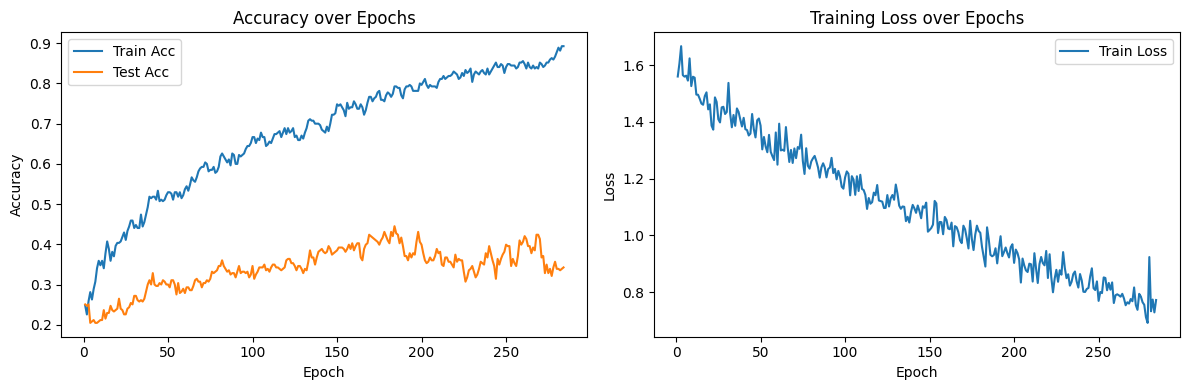

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/1087658332.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/1087658332.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


(270, 22, 33)
(273, 22, 33)


Computing coherence: 100%|██████████| 273/273 [00:19<00:00, 13.84it/s]
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])


Spectral coherence shape: (543, 231)


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
Epochs:  45%|████▍     | 448/1000 [06:17<07:44,  1.19it/s, Train Loss=0.1246, Train Acc=1.0000, Test Acc=0.7582, Test Kappa=0.6776, Best Test Kappa=0.7021 (Epoch 349), Best Test Acc=0.7766 (Epoch 349)]


⏹️ Early stopping at epoch 449. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.7619
📊 Final Test Cohen’s Kappa Score: 0.6825


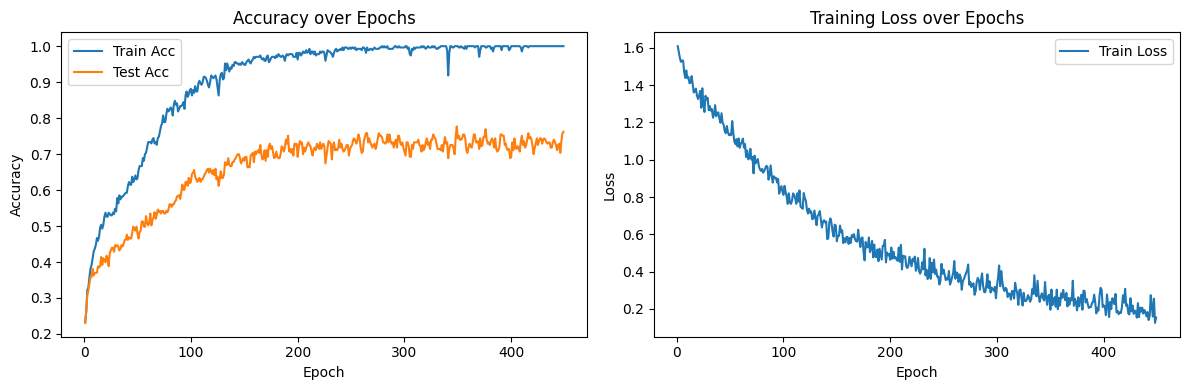

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/1087658332.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/1087658332.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


(262, 22, 33)
(228, 22, 33)


Computing coherence: 100%|██████████| 228/228 [00:16<00:00, 13.68it/s]
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])


Spectral coherence shape: (490, 231)


Epochs:  47%|████▋     | 466/1000 [06:16<07:11,  1.24it/s, Train Loss=0.6171, Train Acc=0.9618, Test Acc=0.5833, Test Kappa=0.4447, Best Test Kappa=0.5319 (Epoch 367), Best Test Acc=0.6491 (Epoch 367)]


⏹️ Early stopping at epoch 467. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.5965
📊 Final Test Cohen’s Kappa Score: 0.4620


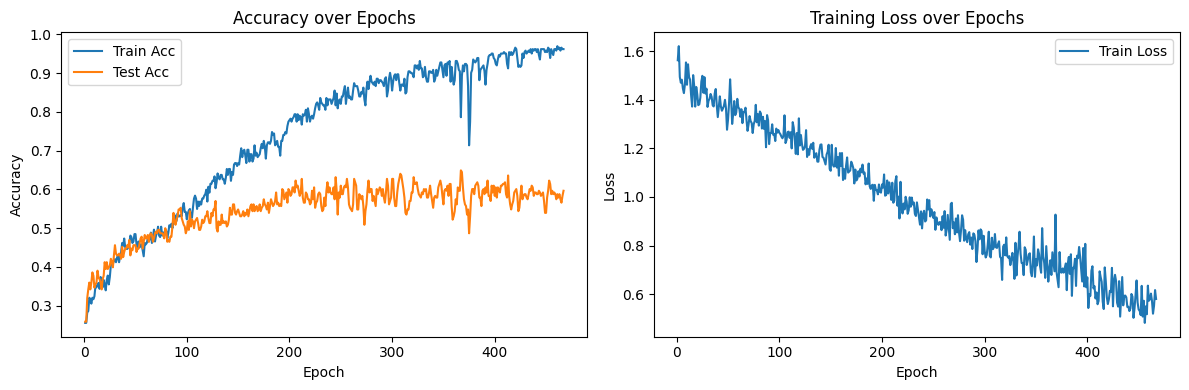

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/1087658332.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/1087658332.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


(262, 22, 33)
(276, 22, 33)


Computing coherence: 100%|██████████| 276/276 [00:19<00:00, 14.07it/s]
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])


Spectral coherence shape: (538, 231)


Epochs:  31%|███       | 310/1000 [04:02<08:59,  1.28it/s, Train Loss=0.8926, Train Acc=0.7710, Test Acc=0.3659, Test Kappa=0.1533, Best Test Kappa=0.2193 (Epoch 211), Best Test Acc=0.4167 (Epoch 211)]


⏹️ Early stopping at epoch 311. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.3623
📊 Final Test Cohen’s Kappa Score: 0.1488


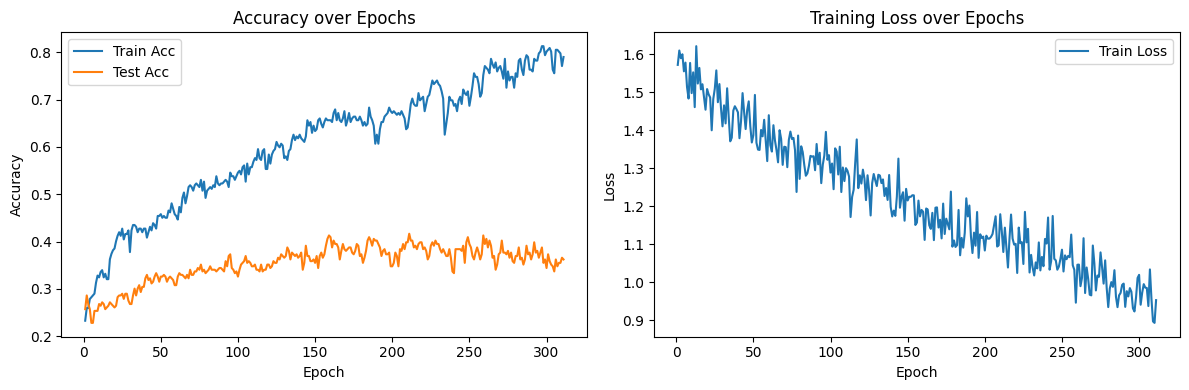

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/1087658332.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/1087658332.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


(219, 22, 33)
(215, 22, 33)


Computing coherence: 100%|██████████| 215/215 [00:15<00:00, 14.06it/s]
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])


Spectral coherence shape: (434, 231)


Epochs:  11%|█         | 108/1000 [01:16<10:35,  1.40it/s, Train Loss=1.2922, Train Acc=0.5434, Test Acc=0.2930, Test Kappa=0.0558, Best Test Kappa=0.1072 (Epoch 9), Best Test Acc=0.3302 (Epoch 9)]


⏹️ Early stopping at epoch 109. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.2884
📊 Final Test Cohen’s Kappa Score: 0.0495


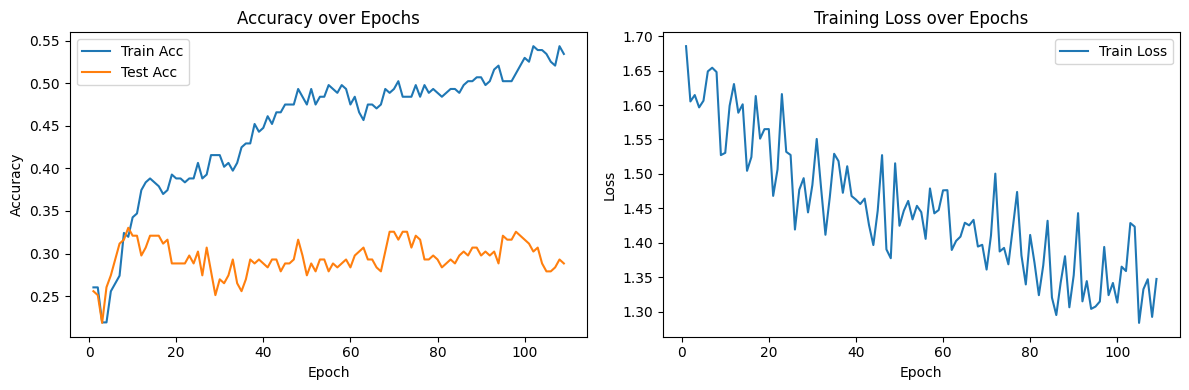

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/1087658332.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/1087658332.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


(271, 22, 33)
(277, 22, 33)


Computing coherence: 100%|██████████| 277/277 [00:19<00:00, 13.89it/s]
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])


Spectral coherence shape: (548, 231)


Epochs:  53%|█████▎    | 533/1000 [07:50<06:52,  1.13it/s, Train Loss=0.1173, Train Acc=1.0000, Test Acc=0.7437, Test Kappa=0.6581, Best Test Kappa=0.7110 (Epoch 434), Best Test Acc=0.7834 (Epoch 434)]


⏹️ Early stopping at epoch 534. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.7690
📊 Final Test Cohen’s Kappa Score: 0.6917


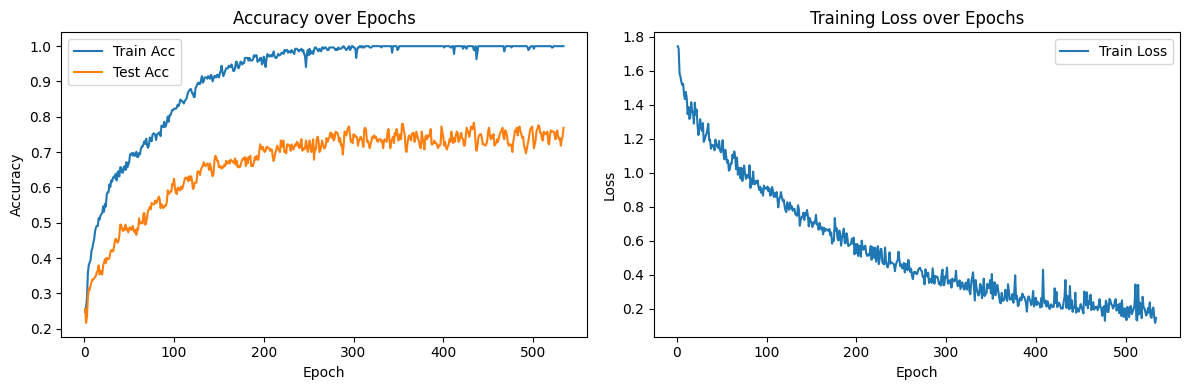

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/1087658332.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/1087658332.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


(264, 22, 33)
(271, 22, 33)


Computing coherence: 100%|██████████| 271/271 [00:19<00:00, 13.56it/s]
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])


Spectral coherence shape: (535, 231)


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
Epochs:  42%|████▏     | 415/1000 [05:42<08:02,  1.21it/s, Train Loss=0.3920, Train Acc=0.9924, Test Acc=0.7269, Test Kappa=0.6361, Best Test Kappa=0.6459 (Epoch 413), Best Test Acc=0.7343 (Epoch 413)]


⏹️ Early stopping at epoch 416. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.7269
📊 Final Test Cohen’s Kappa Score: 0.6359


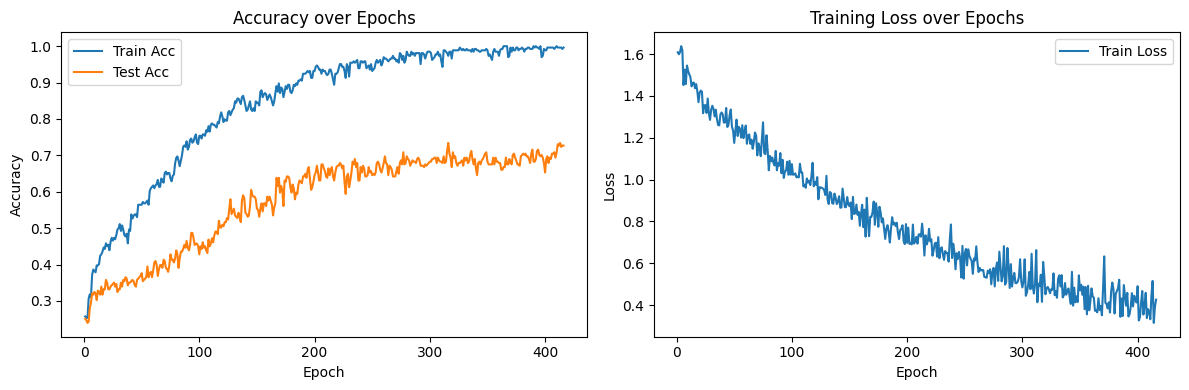

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/1087658332.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/1087658332.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


(237, 22, 33)
(264, 22, 33)


Computing coherence: 100%|██████████| 264/264 [00:18<00:00, 13.98it/s]
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_20334/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])


Spectral coherence shape: (501, 231)


Epochs:  31%|███       | 307/1000 [03:40<08:18,  1.39it/s, Train Loss=0.3644, Train Acc=0.9958, Test Acc=0.7538, Test Kappa=0.6716, Best Test Kappa=0.7425 (Epoch 208), Best Test Acc=0.8068 (Epoch 208)]


⏹️ Early stopping at epoch 308. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.7462
📊 Final Test Cohen’s Kappa Score: 0.6614


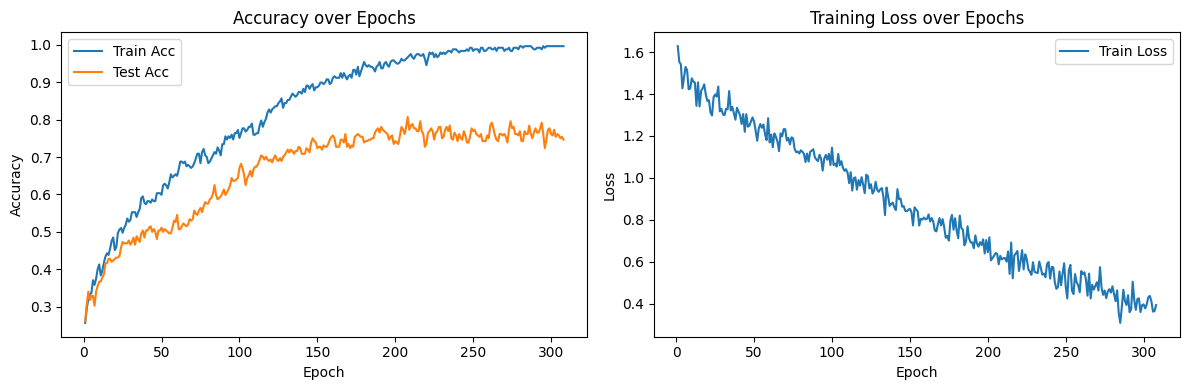

FileNotFoundError: [Errno 2] No such file or directory: 'BCI_Kaggle/A010T.mat'

In [43]:
import torch
from torch_geometric.loader import DataLoader
from sklearn.metrics import accuracy_score
from tqdm import tqdm, trange
import matplotlib.pyplot as plt

for subi in range(1,10):
    train_data, train_label = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=True, all_trials=False)
    test_data, test_label = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=False, all_trials=False)
    tr_features, train_csp = extract_features(train_data, train_label, fs=250, n_csp_components=2)
    te_features, test_csp = extract_features(test_data, test_label, fs=250, n_csp_components=2)
    train_features = np.concatenate(
        [tr_features, np.repeat(train_csp[:, np.newaxis, :], tr_features.shape[1], axis=1)],
        axis=-1
    )

    test_features = np.concatenate(
        [te_features, np.repeat(test_csp[:, np.newaxis, :], te_features.shape[1], axis=1)],
        axis=-1
    )
    print(train_features.shape)  # should be (270, 22, 33) → 17 channel features + 16 CSP features
    print(test_features.shape)   # should be (283, 22, 33)
    train_spec_coh = compute_spectral_coherence(train_data, sfreq=250)
    test_spec_coh  = compute_spectral_coherence(test_data, sfreq=250)

    # Combine and save
    spec_coh_values = np.vstack([train_spec_coh, test_spec_coh])
    np.save("../spec_coh_values.npy", spec_coh_values)

    print(f"Spectral coherence shape: {spec_coh_values.shape}")
    train_dataset = EEGGraphDataset(
        X=train_features, 
        y=train_label, 
        indices=np.arange(len(train_label)), 
        loader_type="train", 
        sfreq=250
    )

    test_dataset = EEGGraphDataset(
        X=test_features, 
        y=test_label, 
        indices=np.arange(len(test_label)), 
        loader_type="test", 
        sfreq=250
    )


    # 1. Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # 2. Instantiate Model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = GraphTransformerNet(in_channels=33, hidden_channels=32, out_channels=4, K=3,transformer_heads=4 )

    # 3. Define optimizer and loss function
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=5e-4)
    criterion = torch.nn.CrossEntropyLoss()

    # 4. Train Function
    def train_model(model, train_loader):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            loss = criterion(out, batch.y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(train_loader)
    from sklearn.metrics import cohen_kappa_score
    # 5. Evaluate Function
    def evaluate_model(model, data_loader, return_preds=False):
        model.eval()
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for batch in data_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
                preds = torch.argmax(out, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(batch.y.cpu().numpy())
        acc = accuracy_score(all_labels, all_preds)
        kappa = cohen_kappa_score(all_labels, all_preds)
        if return_preds:
            return acc, kappa, all_labels, all_preds
        return acc, kappa

    # 6. Training Loop with Progress Bar and Metrics Logging
    # 6. Training Loop with Early Stopping and Progress Bar
    num_epochs = 1000
    patience = 100
    early_stop_counter = 0

    best_test_acc = 0.0
    best_epoch = 0
    best_model_state = None
    best_test_kappa = 0.0
    train_losses = []
    train_accuracies = []
    test_accuracies = []

    epoch_bar = trange(1, num_epochs + 1, desc="Epochs", leave=True)

    for epoch in epoch_bar:
        train_loss = train_model(model, train_loader)
        train_acc, train_kappa = evaluate_model(model, train_loader)
        test_acc, test_kappa = evaluate_model(model, test_loader)

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)
        
        if test_kappa>best_test_kappa:
            best_test_kappa = test_kappa
            best_epoch = epoch
            best_model_state = model.state_dict()
        # Check for improvement
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_epoch = epoch
            best_model_state = model.state_dict()  # Save best model
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        # Early stopping condition
        if early_stop_counter >= patience:
            print(f"\n⏹️ Early stopping at epoch {epoch}. No improvement for {patience} consecutive epochs.")
            break

        epoch_bar.set_postfix({
            'Train Loss': f'{train_loss:.4f}',
            'Train Acc': f'{train_acc:.4f}',
            'Test Acc': f'{test_acc:.4f}',
            'Test Kappa': f'{test_kappa:.4f}',
            'Best Test Kappa': f'{best_test_kappa:.4f} (Epoch {best_epoch})',
            'Best Test Acc': f'{best_test_acc:.4f} (Epoch {best_epoch})'
        })
    # Load the best model state before evaluation
    if best_model_state:
        model.load_state_dict(best_model_state)

    final_acc, final_kappa = evaluate_model(model, test_loader)
    print(f"\n✅ Final Test Accuracy: {final_acc:.4f}")
    print(f"📊 Final Test Cohen’s Kappa Score: {final_kappa:.4f}")


    # 7. Optional: Plot Learning Curves
    def plot_learning_curves(train_losses, train_accuracies, test_accuracies):
        epochs = list(range(1, len(train_losses) + 1))

        plt.figure(figsize=(12, 4))

        # Accuracy Plot
        plt.subplot(1, 2, 1)
        plt.plot(epochs, train_accuracies, label='Train Acc')
        plt.plot(epochs, test_accuracies, label='Test Acc')
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy over Epochs")
        plt.legend()

        # Loss Plot
        plt.subplot(1, 2, 2)
        plt.plot(epochs, train_losses, label='Train Loss')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss over Epochs")
        plt.legend()

        plt.tight_layout()
        plt.show()

    # Call the plotting function
    plot_learning_curves(train_losses, train_accuracies, test_accuracies)

In [12]:
batch_size

2

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GraphConv, ChebConv, SAGEConv, global_mean_pool

# --- GNN Blocks with LayerNorm ---

class GraphConvBlock(nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GraphConv(in_channels, hidden_channels)
        self.ln1 = nn.LayerNorm(hidden_channels)
        self.conv2 = GraphConv(hidden_channels, hidden_channels)
        self.ln2 = nn.LayerNorm(hidden_channels)
        self.conv3 = GraphConv(hidden_channels, hidden_channels // 2)
        self.ln3 = nn.LayerNorm(hidden_channels // 2)

    def forward(self, x, edge_index, edge_weight, batch):
        x = F.relu(self.ln1(self.conv1(x, edge_index, edge_weight)))
        x = F.relu(self.ln2(self.conv2(x, edge_index, edge_weight)))
        x = F.relu(self.ln3(self.conv3(x, edge_index, edge_weight)))
        return global_mean_pool(x, batch)

class ChebConvBlock(nn.Module):
    def __init__(self, in_channels, hidden_channels, K=3):
        super().__init__()
        self.conv1 = ChebConv(in_channels, hidden_channels, K)
        self.ln1 = nn.LayerNorm(hidden_channels)
        self.conv2 = ChebConv(hidden_channels, hidden_channels, K)
        self.ln2 = nn.LayerNorm(hidden_channels)
        self.conv3 = ChebConv(hidden_channels, hidden_channels // 2, K)
        self.ln3 = nn.LayerNorm(hidden_channels // 2)

    def forward(self, x, edge_index, edge_weight, batch):
        x = F.relu(self.ln1(self.conv1(x, edge_index, edge_weight)))
        x = F.relu(self.ln2(self.conv2(x, edge_index, edge_weight)))
        x = F.relu(self.ln3(self.conv3(x, edge_index, edge_weight)))
        return global_mean_pool(x, batch)

class SAGEConvBlock(nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.ln1 = nn.LayerNorm(hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.ln2 = nn.LayerNorm(hidden_channels)
        self.conv3 = SAGEConv(hidden_channels, hidden_channels // 2)
        self.ln3 = nn.LayerNorm(hidden_channels // 2)

    def forward(self, x, edge_index, edge_weight, batch):
        x = F.relu(self.ln1(self.conv1(x, edge_index)))
        x = F.relu(self.ln2(self.conv2(x, edge_index)))
        x = F.relu(self.ln3(self.conv3(x, edge_index)))
        return global_mean_pool(x, batch)

# --- Transformer Block (unchanged) ---

class TransformerBlock(nn.Module):
    def __init__(self, input_dim, nhead=4, num_layers=1, dim_feedforward=256):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=input_dim,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, x):
        return self.transformer(x)

# --- Combined GNN + Transformer Model with LayerNorm ---

class GraphTransformerNet(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, K=3, transformer_heads=4, transformer_layers=3,dropouts=0.5):
        super().__init__()
        self.graph_block = GraphConvBlock(in_channels, hidden_channels)
        self.cheb_block = ChebConvBlock(in_channels, hidden_channels, K)
        self.sage_block = SAGEConvBlock(in_channels, hidden_channels)

        self.feature_dim = (hidden_channels // 2) * 3
        assert self.feature_dim % transformer_heads == 0, "embed_dim must be divisible by num_heads"

        self.transformer = TransformerBlock(
            input_dim=self.feature_dim,
            nhead=transformer_heads,
            num_layers=transformer_layers
        )

        self.mlp = nn.Sequential(
            nn.Linear(self.feature_dim, hidden_channels),
            nn.ReLU(),
            nn.LayerNorm(hidden_channels),
            nn.Dropout(dropouts),
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.LayerNorm(hidden_channels // 2),
            nn.Dropout(dropouts),
            nn.Linear(hidden_channels // 2, out_channels)
        )

    def forward(self, x, edge_index, edge_weight, batch):
        g1 = self.graph_block(x, edge_index, edge_weight, batch)
        g2 = self.cheb_block(x, edge_index, edge_weight, batch)
        g3 = self.sage_block(x, edge_index, edge_weight, batch)

        x = torch.cat([g1, g2, g3], dim=1)

        x = x.unsqueeze(1)  # (batch_size, seq_len=1, feature_dim)
        x = self.transformer(x)
        x = x[:, 0, :]  # back to (batch_size, feature_dim)

        return self.mlp(x)

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


(273, 22, 16)
(281, 22, 16)


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/669837760.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/669837760.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
Epochs:  27%|██▋       | 273/1000 [04:05<10:54,  1.11it/s, Train Loss=0.1761, Train Acc=0.9853, Test Acc=0.8256, Test Kappa=0.7675, Best Test Kappa=0.8008 (Epoch 174), Best Test Acc=0.8505 (Epoch 174)]


⏹️ Early stopping at epoch 274. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.8327
📊 Final Test Cohen’s Kappa Score: 0.7770


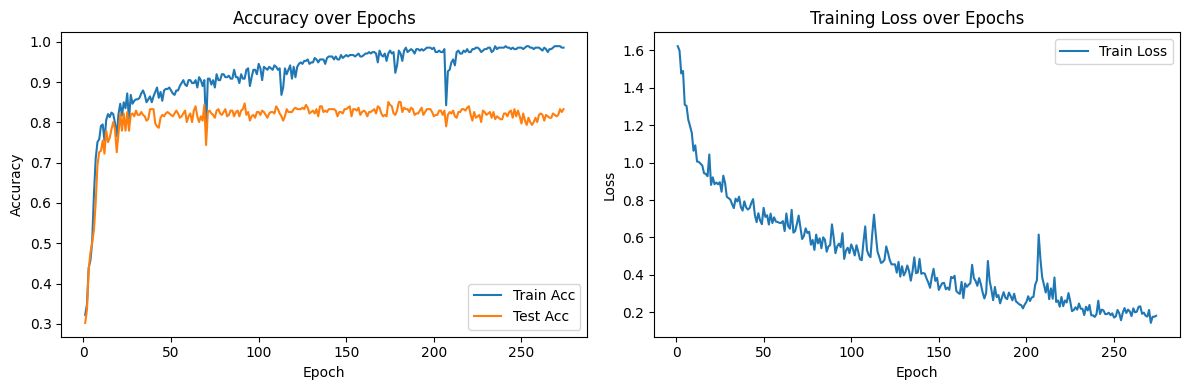

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


(270, 22, 16)
(283, 22, 16)


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/669837760.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/669837760.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
Epochs:  13%|█▎        | 130/1000 [02:23<16:00,  1.10s/it, Train Loss=0.6930, Train Acc=0.7963, Test Acc=0.5300, Test Kappa=0.3742, Best Test Kappa=0.4630 (Epoch 31), Best Test Acc=0.5972 (Epoch 31)]


⏹️ Early stopping at epoch 131. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.5300
📊 Final Test Cohen’s Kappa Score: 0.3740


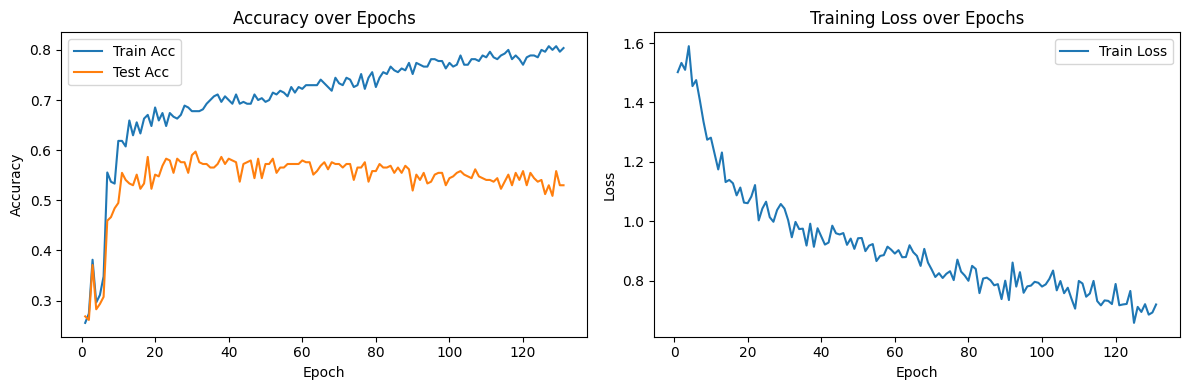

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


(270, 22, 16)
(273, 22, 16)


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/669837760.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/669837760.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
Epochs:  21%|██        | 210/1000 [03:33<13:21,  1.01s/it, Train Loss=0.1479, Train Acc=0.9963, Test Acc=0.8242, Test Kappa=0.7655, Best Test Kappa=0.8095 (Epoch 113), Best Test Acc=0.8571 (Epoch 113)]


⏹️ Early stopping at epoch 211. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.8132
📊 Final Test Cohen’s Kappa Score: 0.7508


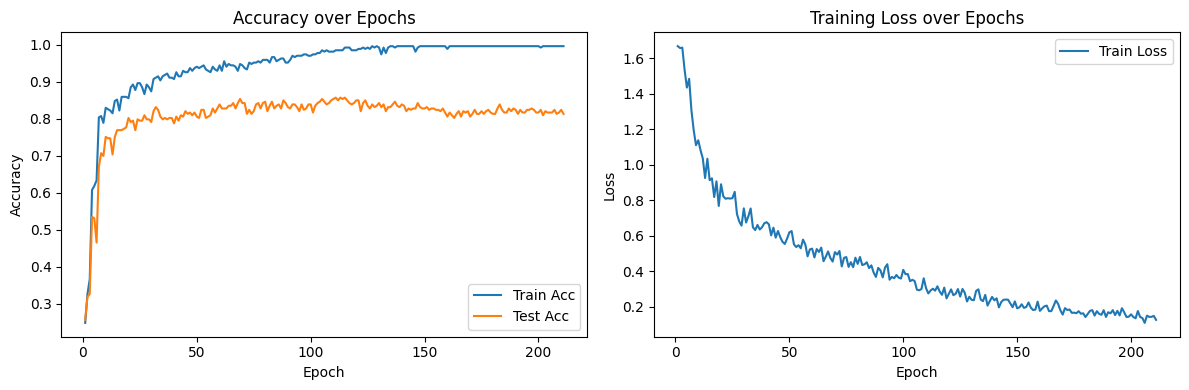

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


(262, 22, 16)
(228, 22, 16)


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/669837760.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/669837760.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
Epochs:  15%|█▌        | 151/1000 [02:26<13:43,  1.03it/s, Train Loss=0.5919, Train Acc=0.8931, Test Acc=0.6535, Test Kappa=0.5392, Best Test Kappa=0.5793 (Epoch 67), Best Test Acc=0.6842 (Epoch 67)]


⏹️ Early stopping at epoch 152. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.6053
📊 Final Test Cohen’s Kappa Score: 0.4748


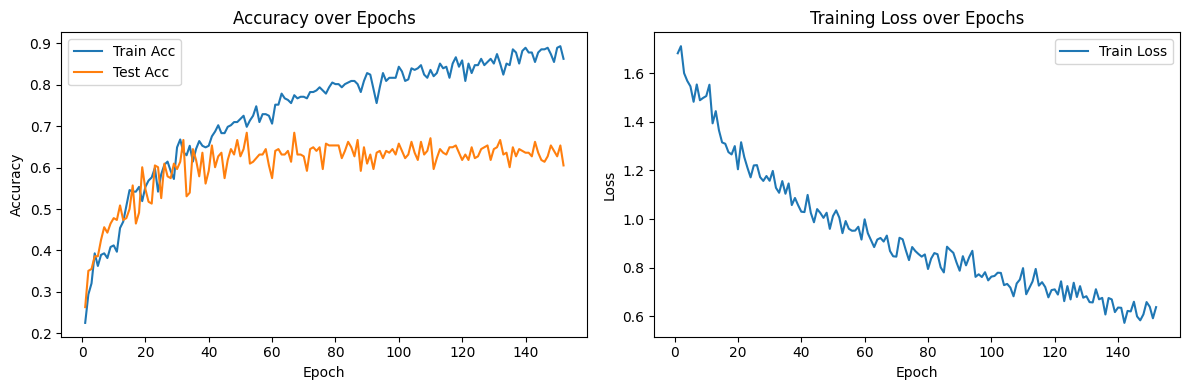

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


(262, 22, 16)
(276, 22, 16)


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/669837760.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/669837760.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
Epochs:  36%|███▌      | 357/1000 [06:22<11:29,  1.07s/it, Train Loss=0.5009, Train Acc=0.8893, Test Acc=0.4348, Test Kappa=0.2463, Best Test Kappa=0.3090 (Epoch 258), Best Test Acc=0.4819 (Epoch 258)]


⏹️ Early stopping at epoch 358. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.4384
📊 Final Test Cohen’s Kappa Score: 0.2523


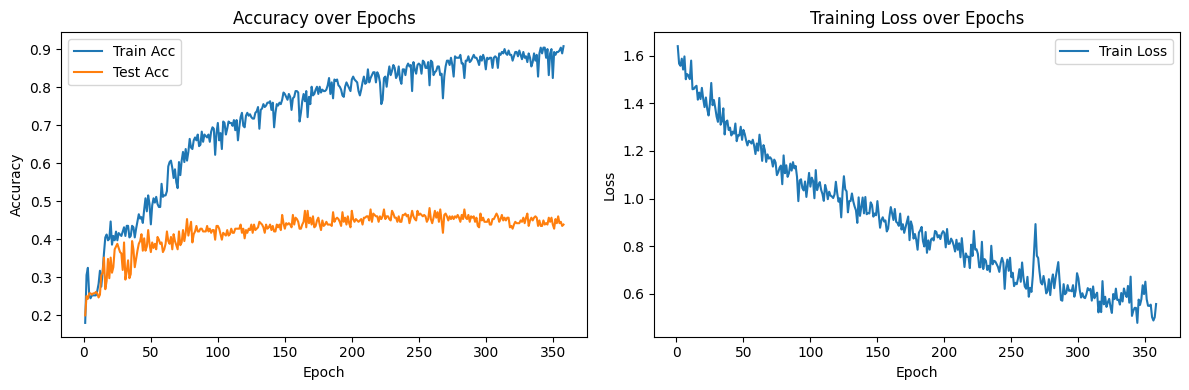

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


(219, 22, 16)
(215, 22, 16)


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/669837760.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/669837760.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
Epochs:  16%|█▌        | 162/1000 [02:27<12:41,  1.10it/s, Train Loss=0.6386, Train Acc=0.8767, Test Acc=0.5721, Test Kappa=0.4299, Best Test Kappa=0.4665 (Epoch 63), Best Test Acc=0.6000 (Epoch 63)]


⏹️ Early stopping at epoch 163. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.5581
📊 Final Test Cohen’s Kappa Score: 0.4107


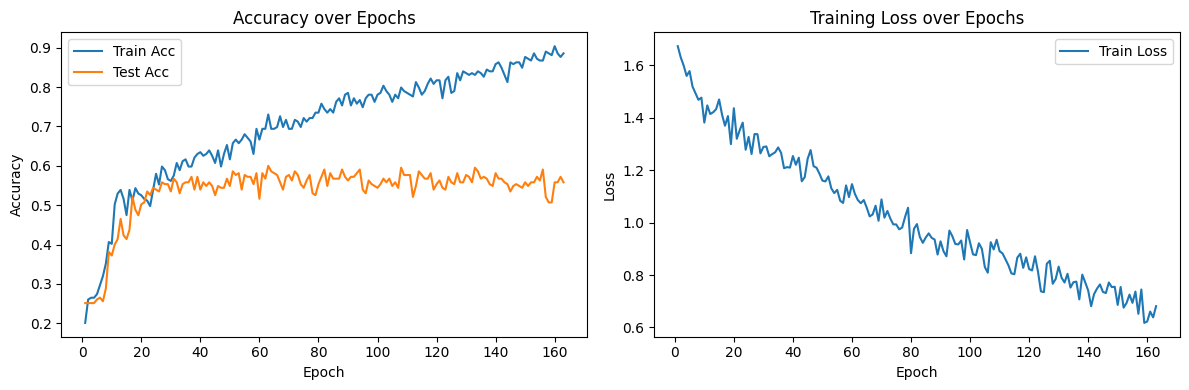

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


(271, 22, 16)
(277, 22, 16)


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/669837760.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/669837760.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
Epochs:  23%|██▎       | 231/1000 [04:25<14:44,  1.15s/it, Train Loss=0.1526, Train Acc=0.9926, Test Acc=0.8700, Test Kappa=0.8269, Best Test Kappa=0.8701 (Epoch 132), Best Test Acc=0.9025 (Epoch 132)]


⏹️ Early stopping at epoch 232. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.8628
📊 Final Test Cohen’s Kappa Score: 0.8173


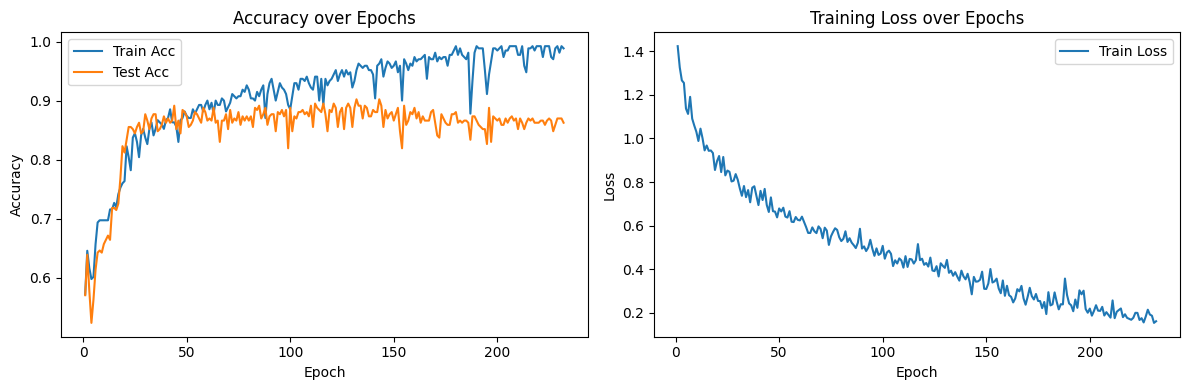

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


(264, 22, 16)
(271, 22, 16)


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/669837760.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/669837760.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
Epochs:  40%|███▉      | 399/1000 [09:34<14:25,  1.44s/it, Train Loss=0.0855, Train Acc=0.9962, Test Acc=0.8376, Test Kappa=0.7836, Best Test Kappa=0.8033 (Epoch 300), Best Test Acc=0.8524 (Epoch 300)]


⏹️ Early stopping at epoch 400. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.8266
📊 Final Test Cohen’s Kappa Score: 0.7688


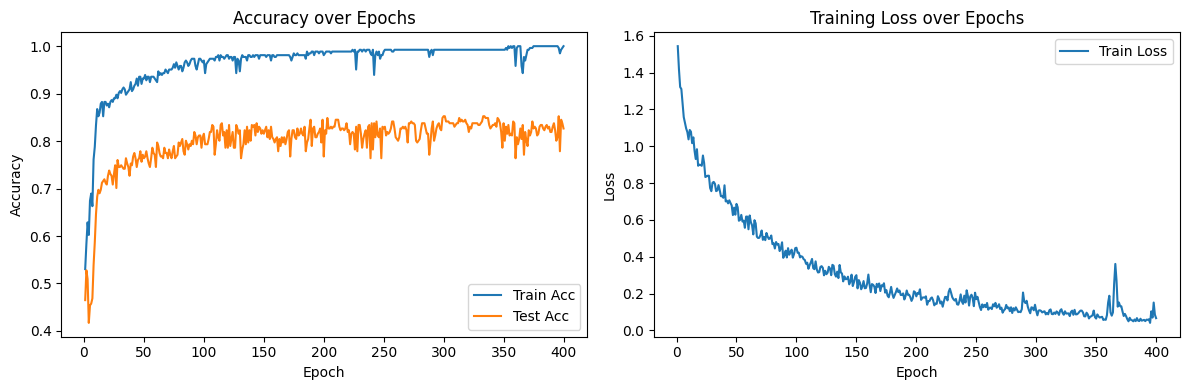

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


(237, 22, 16)
(264, 22, 16)


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/669837760.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/669837760.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
Epochs:  21%|██        | 207/1000 [04:38<17:47,  1.35s/it, Train Loss=0.3494, Train Acc=0.9620, Test Acc=0.8523, Test Kappa=0.8030, Best Test Kappa=0.8434 (Epoch 108), Best Test Acc=0.8826 (Epoch 108)]


⏹️ Early stopping at epoch 208. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.8409
📊 Final Test Cohen’s Kappa Score: 0.7879


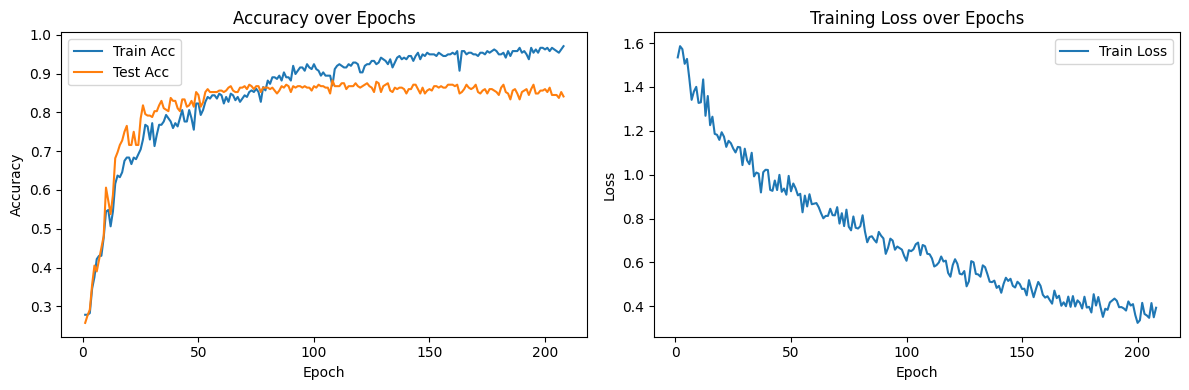

In [14]:
import torch
from torch_geometric.loader import DataLoader
from sklearn.metrics import accuracy_score
from tqdm import tqdm, trange
import matplotlib.pyplot as plt

for subi in range(0,9):
    train_data, train_label = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=True, all_trials=True)
    test_data, test_label = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=False, all_trials=True)
    tr_features, train_csp = extract_features(train_data, train_label, fs=250, n_csp_components=2)
    te_features, test_csp = extract_features(test_data, test_label, fs=250, n_csp_components=2)
    # train_features = np.concatenate(
    #     [tr_features, np.repeat(train_csp[:, np.newaxis, :], tr_features.shape[1], axis=1)],
    #     axis=-1
    # )

    # test_features = np.concatenate(
    #     [te_features, np.repeat(test_csp[:, np.newaxis, :], te_features.shape[1], axis=1)],
    #     axis=-1
    # )
    train_features = np.repeat(train_csp[:, np.newaxis, :], 22, axis=1)  # shape: (trials, channels, csp_features)
    test_features  = np.repeat(test_csp[:,  np.newaxis, :], 22, axis=1)
    print(train_features.shape)  # should be (270, 22, 33) → 17 channel features + 16 CSP features
    print(test_features.shape)   # should be (283, 22, 33)
    # train_spec_coh = compute_spectral_coherence(train_data, sfreq=250)
    # test_spec_coh  = compute_spectral_coherence(test_data, sfreq=250)

    # # Combine and save
    # spec_coh_values = np.vstack([train_spec_coh, test_spec_coh])
    # np.save("../spec_coh_values.npy", spec_coh_values)

    # print(f"Spectral coherence shape: {spec_coh_values.shape}")
    train_dataset = EEGGraphDataset(
        X=train_features, 
        y=train_label, 
        indices=np.arange(len(train_label)), 
        loader_type="train", 
        sfreq=250
    )

    test_dataset = EEGGraphDataset(
        X=test_features, 
        y=test_label, 
        indices=np.arange(len(test_label)), 
        loader_type="test", 
        sfreq=250
    )


    # 1. Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

    # 2. Instantiate Model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = GraphTransformerNet(in_channels=16, hidden_channels=32, out_channels=4, K=3, transformer_heads=6)

    # 3. Define optimizer and loss function
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=5e-4)
    criterion = torch.nn.CrossEntropyLoss()

    # 4. Train Function
    def train_model(model, train_loader):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            loss = criterion(out, batch.y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(train_loader)
    from sklearn.metrics import cohen_kappa_score
    # 5. Evaluate Function
    def evaluate_model(model, data_loader, return_preds=False):
        model.eval()
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for batch in data_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
                preds = torch.argmax(out, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(batch.y.cpu().numpy())
        acc = accuracy_score(all_labels, all_preds)
        kappa = cohen_kappa_score(all_labels, all_preds)
        if return_preds:
            return acc, kappa, all_labels, all_preds
        return acc, kappa

    # 6. Training Loop with Progress Bar and Metrics Logging
    # 6. Training Loop with Early Stopping and Progress Bar
    num_epochs = 1000
    patience = 100
    early_stop_counter = 0

    best_test_acc = 0.0
    best_epoch = 0
    best_model_state = None
    best_test_kappa = 0.0
    train_losses = []
    train_accuracies = []
    test_accuracies = []

    epoch_bar = trange(1, num_epochs + 1, desc="Epochs", leave=True)

    for epoch in epoch_bar:
        train_loss = train_model(model, train_loader)
        train_acc, train_kappa = evaluate_model(model, train_loader)
        test_acc, test_kappa = evaluate_model(model, test_loader)

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)
        
        if test_kappa>best_test_kappa:
            best_test_kappa = test_kappa
            best_epoch = epoch
            best_model_state = model.state_dict()
        # Check for improvement
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_epoch = epoch
            best_model_state = model.state_dict()  # Save best model
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        # Early stopping condition
        if early_stop_counter >= patience:
            print(f"\n⏹️ Early stopping at epoch {epoch}. No improvement for {patience} consecutive epochs.")
            break

        epoch_bar.set_postfix({
            'Train Loss': f'{train_loss:.4f}',
            'Train Acc': f'{train_acc:.4f}',
            'Test Acc': f'{test_acc:.4f}',
            'Test Kappa': f'{test_kappa:.4f}',
            'Best Test Kappa': f'{best_test_kappa:.4f} (Epoch {best_epoch})',
            'Best Test Acc': f'{best_test_acc:.4f} (Epoch {best_epoch})'
        })
    # Load the best model state before evaluation
    if best_model_state:
        model.load_state_dict(best_model_state)

    final_acc, final_kappa = evaluate_model(model, test_loader)
    print(f"\n✅ Final Test Accuracy: {final_acc:.4f}")
    print(f"📊 Final Test Cohen’s Kappa Score: {final_kappa:.4f}")


    # 7. Optional: Plot Learning Curves
    def plot_learning_curves(train_losses, train_accuracies, test_accuracies):
        epochs = list(range(1, len(train_losses) + 1))

        plt.figure(figsize=(12, 4))

        # Accuracy Plot
        plt.subplot(1, 2, 1)
        plt.plot(epochs, train_accuracies, label='Train Acc')
        plt.plot(epochs, test_accuracies, label='Test Acc')
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy over Epochs")
        plt.legend()

        # Loss Plot
        plt.subplot(1, 2, 2)
        plt.plot(epochs, train_losses, label='Train Loss')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss over Epochs")
        plt.legend()

        plt.tight_layout()
        plt.show()

    # Call the plotting function
    plot_learning_curves(train_losses, train_accuracies, test_accuracies)

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


(273, 22, 16)
(281, 22, 16)


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
Epochs:  18%|█▊        | 179/1000 [02:26<11:13,  1.22it/s, Train Loss=0.4256, Train Acc=0.9963, Test Acc=0.7794, Test Kappa=0.7057, Best Test Kappa=0.7580 (Epoch 80), Best Test Acc=0.8185 (Epoch 80)]


⏹️ Early stopping at epoch 180. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.7722
📊 Final Test Cohen’s Kappa Score: 0.6963


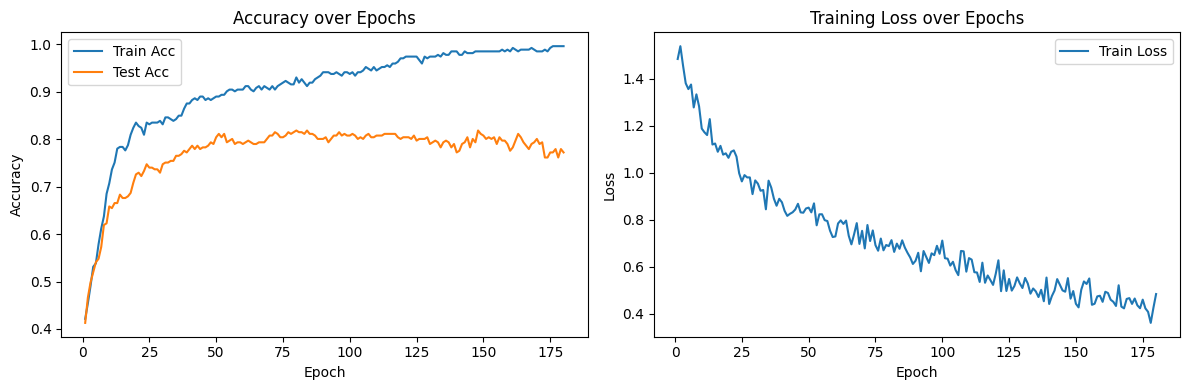

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


(270, 22, 16)
(283, 22, 16)


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
Epochs:  18%|█▊        | 176/1000 [02:34<12:03,  1.14it/s, Train Loss=0.7432, Train Acc=0.8889, Test Acc=0.4629, Test Kappa=0.2829, Best Test Kappa=0.3544 (Epoch 77), Best Test Acc=0.5159 (Epoch 77)]


⏹️ Early stopping at epoch 177. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.4452
📊 Final Test Cohen’s Kappa Score: 0.2594


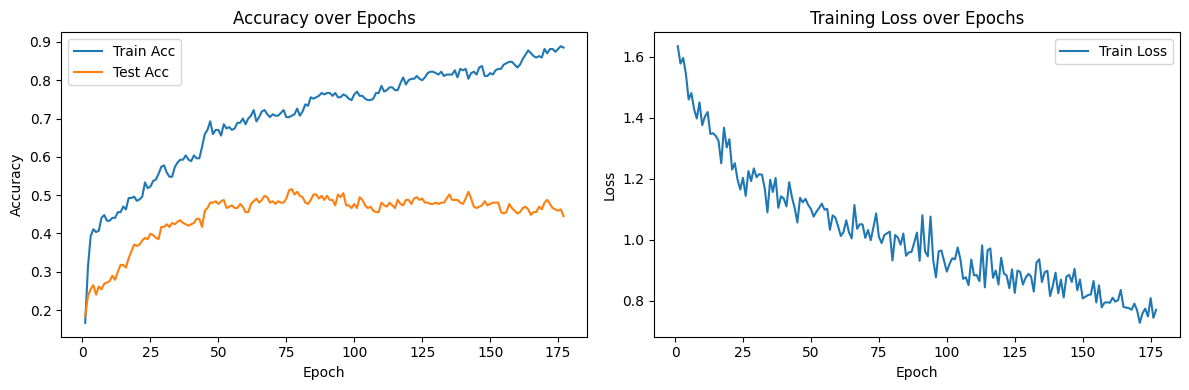

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


(270, 22, 16)
(273, 22, 16)


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
Epochs:  17%|█▋        | 168/1000 [02:36<12:56,  1.07it/s, Train Loss=0.4127, Train Acc=1.0000, Test Acc=0.7839, Test Kappa=0.7117, Best Test Kappa=0.7704 (Epoch 69), Best Test Acc=0.8278 (Epoch 69)]


⏹️ Early stopping at epoch 169. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.7875
📊 Final Test Cohen’s Kappa Score: 0.7166


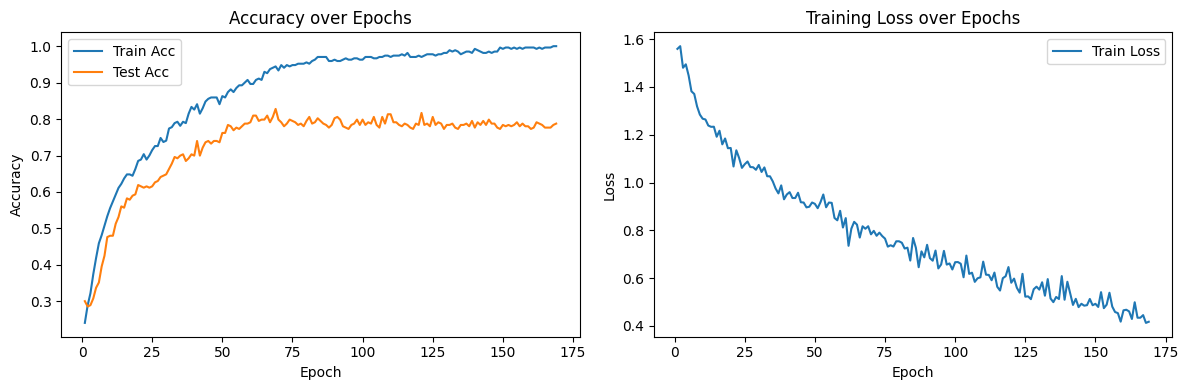

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


(262, 22, 16)
(228, 22, 16)


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
Epochs:  20%|██        | 203/1000 [02:49<11:05,  1.20it/s, Train Loss=0.7540, Train Acc=0.9427, Test Acc=0.5965, Test Kappa=0.4617, Best Test Kappa=0.5794 (Epoch 104), Best Test Acc=0.6842 (Epoch 104)]


⏹️ Early stopping at epoch 204. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.6140
📊 Final Test Cohen’s Kappa Score: 0.4855


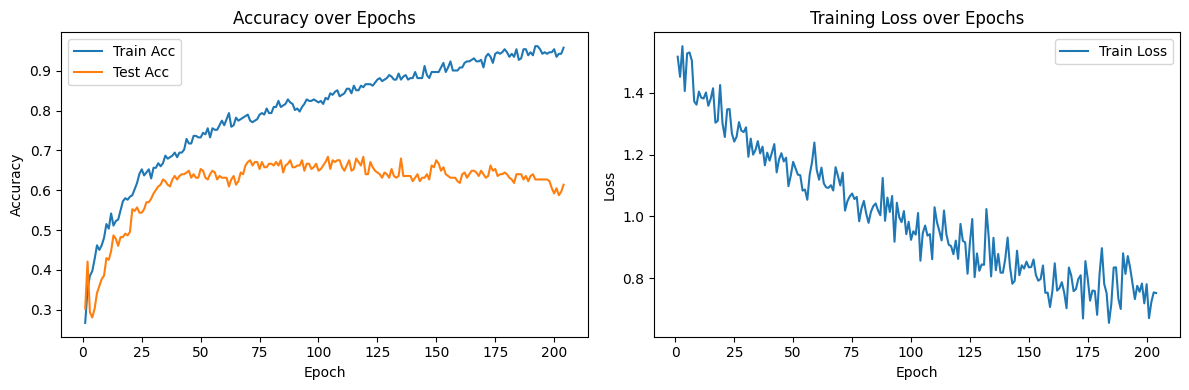

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


(262, 22, 16)
(276, 22, 16)


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
Epochs:  26%|██▌       | 256/1000 [03:29<10:08,  1.22it/s, Train Loss=1.0198, Train Acc=0.8168, Test Acc=0.4275, Test Kappa=0.2368, Best Test Kappa=0.2812 (Epoch 157), Best Test Acc=0.4601 (Epoch 157)]


⏹️ Early stopping at epoch 257. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.4239
📊 Final Test Cohen’s Kappa Score: 0.2324


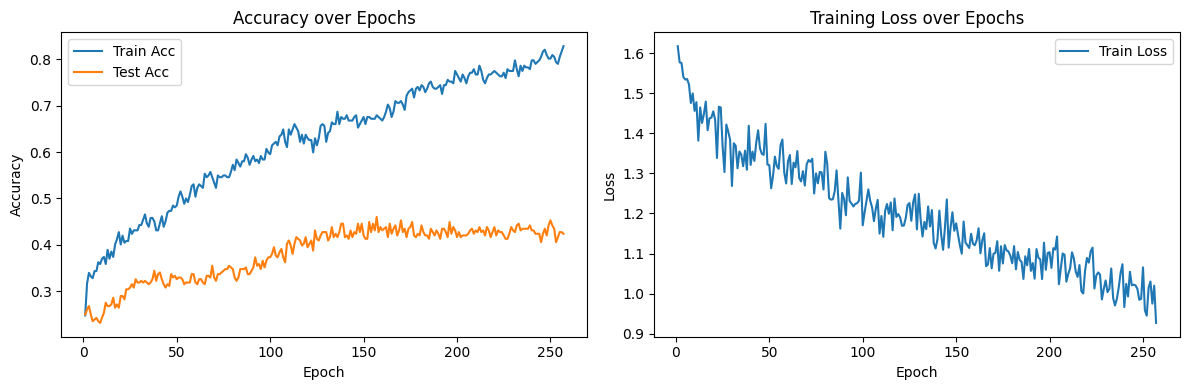

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


(219, 22, 16)
(215, 22, 16)


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
Epochs:  25%|██▍       | 248/1000 [02:47<08:27,  1.48it/s, Train Loss=0.4904, Train Acc=1.0000, Test Acc=0.4977, Test Kappa=0.3309, Best Test Kappa=0.3866 (Epoch 151), Best Test Acc=0.5395 (Epoch 151)]


⏹️ Early stopping at epoch 249. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.5023
📊 Final Test Cohen’s Kappa Score: 0.3371


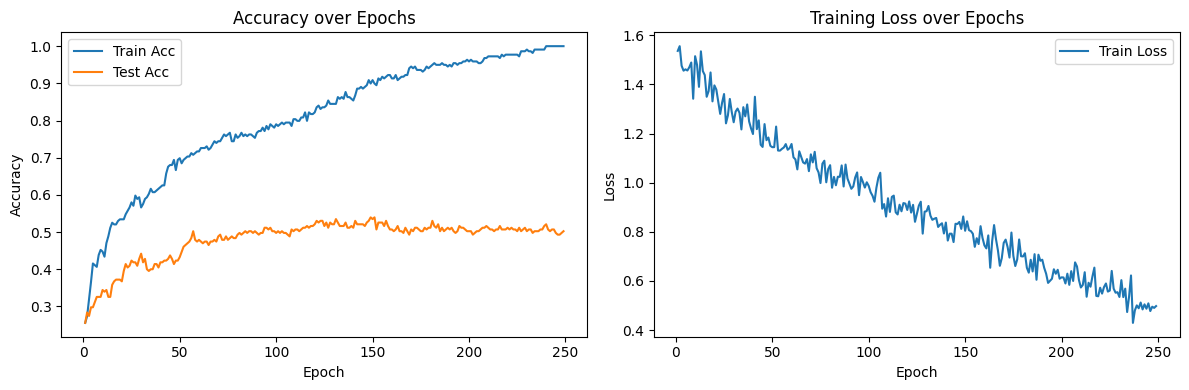

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


(271, 22, 16)
(277, 22, 16)


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
Epochs:  18%|█▊        | 179/1000 [02:31<11:35,  1.18it/s, Train Loss=0.4648, Train Acc=0.9742, Test Acc=0.8809, Test Kappa=0.8411, Best Test Kappa=0.8555 (Epoch 82), Best Test Acc=0.8917 (Epoch 82)]


⏹️ Early stopping at epoch 180. No improvement for 100 consecutive epochs.



✅ Final Test Accuracy: 0.8773
📊 Final Test Cohen’s Kappa Score: 0.8363


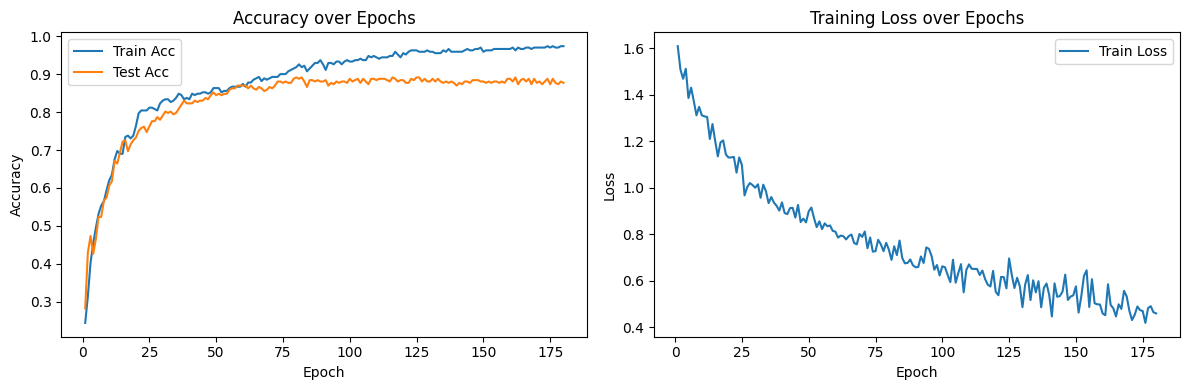

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


(264, 22, 16)
(271, 22, 16)


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
Epochs:  32%|███▎      | 325/1000 [05:06<10:36,  1.06it/s, Train Loss=0.3602, Train Acc=1.0000, Test Acc=0.7786, Test Kappa=0.7049, Best Test Kappa=0.7591 (Epoch 226), Best Test Acc=0.8192 (Epoch 226)]


⏹️ Early stopping at epoch 326. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.7823
📊 Final Test Cohen’s Kappa Score: 0.7098


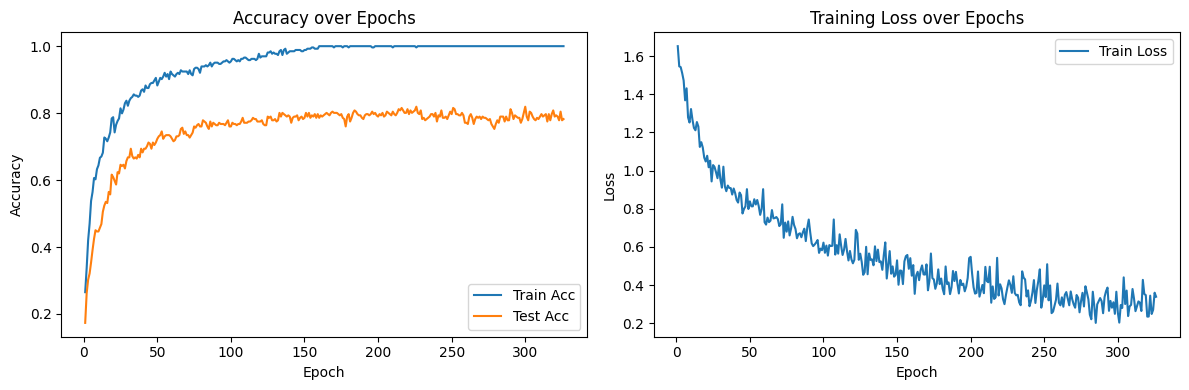

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


(237, 22, 16)
(264, 22, 16)


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
Epochs:  18%|█▊        | 176/1000 [02:19<10:52,  1.26it/s, Train Loss=0.5413, Train Acc=0.9536, Test Acc=0.8409, Test Kappa=0.7879, Best Test Kappa=0.8384 (Epoch 77), Best Test Acc=0.8788 (Epoch 77)]


⏹️ Early stopping at epoch 177. No improvement for 100 consecutive epochs.

✅ Final Test Accuracy: 0.8447
📊 Final Test Cohen’s Kappa Score: 0.7929


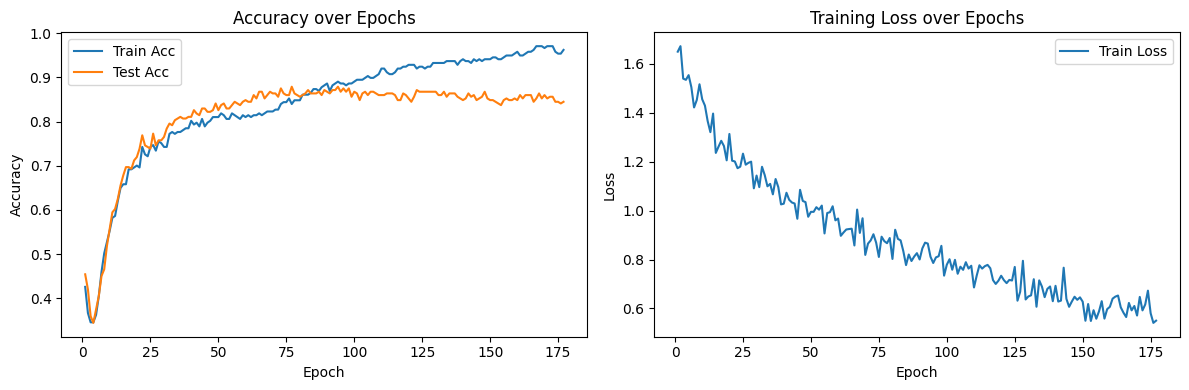

In [182]:
import torch
from torch_geometric.loader import DataLoader
from sklearn.metrics import accuracy_score
from tqdm import tqdm, trange
import matplotlib.pyplot as plt

for subi in range(0,9):
    train_data, train_label = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=True, all_trials=False)
    test_data, test_label = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=False, all_trials=False)
    tr_features, train_csp = extract_features(train_data, train_label, fs=250, n_csp_components=2)
    te_features, test_csp = extract_features(test_data, test_label, fs=250, n_csp_components=2)
    # train_features = np.concatenate(
    #     [tr_features, np.repeat(train_csp[:, np.newaxis, :], tr_features.shape[1], axis=1)],
    #     axis=-1
    # )

    # test_features = np.concatenate(
    #     [te_features, np.repeat(test_csp[:, np.newaxis, :], te_features.shape[1], axis=1)],
    #     axis=-1
    # )
    train_features = np.repeat(train_csp[:, np.newaxis, :], 22, axis=1)  # shape: (trials, channels, csp_features)
    test_features  = np.repeat(test_csp[:,  np.newaxis, :], 22, axis=1)
    print(train_features.shape)  # should be (270, 22, 33) → 17 channel features + 16 CSP features
    print(test_features.shape)   # should be (283, 22, 33)
    # train_spec_coh = compute_spectral_coherence(train_data, sfreq=250)
    # test_spec_coh  = compute_spectral_coherence(test_data, sfreq=250)

    # # Combine and save
    # spec_coh_values = np.vstack([train_spec_coh, test_spec_coh])
    # np.save("../spec_coh_values.npy", spec_coh_values)

    # print(f"Spectral coherence shape: {spec_coh_values.shape}")
    train_dataset = EEGGraphDataset(
        X=train_features, 
        y=train_label, 
        indices=np.arange(len(train_label)), 
        loader_type="train", 
        sfreq=250
    )

    test_dataset = EEGGraphDataset(
        X=test_features, 
        y=test_label, 
        indices=np.arange(len(test_label)), 
        loader_type="test", 
        sfreq=250
    )


    # 1. Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # 2. Instantiate Model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = GraphTransformerNet(in_channels=16, hidden_channels=32, out_channels=4, K=3, transformer_heads=6)

    # 3. Define optimizer and loss function
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=5e-4)
    criterion = torch.nn.CrossEntropyLoss()

    # 4. Train Function
    def train_model(model, train_loader):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            loss = criterion(out, batch.y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(train_loader)
    from sklearn.metrics import cohen_kappa_score
    # 5. Evaluate Function
    def evaluate_model(model, data_loader, return_preds=False):
        model.eval()
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for batch in data_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
                preds = torch.argmax(out, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(batch.y.cpu().numpy())
        acc = accuracy_score(all_labels, all_preds)
        kappa = cohen_kappa_score(all_labels, all_preds)
        if return_preds:
            return acc, kappa, all_labels, all_preds
        return acc, kappa

    # 6. Training Loop with Progress Bar and Metrics Logging
    # 6. Training Loop with Early Stopping and Progress Bar
    num_epochs = 1000
    patience = 100
    early_stop_counter = 0

    best_test_acc = 0.0
    best_epoch = 0
    best_model_state = None
    best_test_kappa = 0.0
    train_losses = []
    train_accuracies = []
    test_accuracies = []

    epoch_bar = trange(1, num_epochs + 1, desc="Epochs", leave=True)

    for epoch in epoch_bar:
        train_loss = train_model(model, train_loader)
        train_acc, train_kappa = evaluate_model(model, train_loader)
        test_acc, test_kappa = evaluate_model(model, test_loader)

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)
        
        if test_kappa>best_test_kappa:
            best_test_kappa = test_kappa
            best_epoch = epoch
            best_model_state = model.state_dict()
        # Check for improvement
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_epoch = epoch
            best_model_state = model.state_dict()  # Save best model
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        # Early stopping condition
        if early_stop_counter >= patience:
            print(f"\n⏹️ Early stopping at epoch {epoch}. No improvement for {patience} consecutive epochs.")
            break

        epoch_bar.set_postfix({
            'Train Loss': f'{train_loss:.4f}',
            'Train Acc': f'{train_acc:.4f}',
            'Test Acc': f'{test_acc:.4f}',
            'Test Kappa': f'{test_kappa:.4f}',
            'Best Test Kappa': f'{best_test_kappa:.4f} (Epoch {best_epoch})',
            'Best Test Acc': f'{best_test_acc:.4f} (Epoch {best_epoch})'
        })
    # Load the best model state before evaluation
    if best_model_state:
        model.load_state_dict(best_model_state)

    final_acc, final_kappa = evaluate_model(model, test_loader)
    print(f"\n✅ Final Test Accuracy: {final_acc:.4f}")
    print(f"📊 Final Test Cohen’s Kappa Score: {final_kappa:.4f}")


    # 7. Optional: Plot Learning Curves
    def plot_learning_curves(train_losses, train_accuracies, test_accuracies):
        epochs = list(range(1, len(train_losses) + 1))

        plt.figure(figsize=(12, 4))

        # Accuracy Plot
        plt.subplot(1, 2, 1)
        plt.plot(epochs, train_accuracies, label='Train Acc')
        plt.plot(epochs, test_accuracies, label='Test Acc')
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy over Epochs")
        plt.legend()

        # Loss Plot
        plt.subplot(1, 2, 2)
        plt.plot(epochs, train_losses, label='Train Loss')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss over Epochs")
        plt.legend()

        plt.tight_layout()
        plt.show()

    # Call the plotting function
    plot_learning_curves(train_losses, train_accuracies, test_accuracies)

In [22]:
from tqdm import trange
import numpy as np
import torch
from torch.utils.data import random_split
from torch_geometric.loader import DataLoader
from sklearn.metrics import accuracy_score, cohen_kappa_score
import matplotlib.pyplot as plt
from sklearn.model_selection import ParameterGrid
import json
import os
from datetime import datetime

# Create directory for hyperparameter tuning results
os.makedirs('hyperparameter_results', exist_ok=True)

# Define hyperparameter search space
param_grid = {
    'learning_rate': [0.001, 0.0005, 0.0001],
    'weight_decay': [1e-4, 5e-4, 1e-3],
    'hidden_channels': [16, 32, 64],
    'transformer_heads': [2, 4, 8],
    'batch_size': [8,16],
    'dropout': [0.1, 0.3, 0.5]  # Adding dropout as a tunable parameter
}

# Generate all parameter combinations
param_combinations = list(ParameterGrid(param_grid))
print(f"Total parameter combinations to try: {len(param_combinations)}")

# Track results
results = []

# Loop through subjects
for subi in range(0, 9):  # Assuming 9 subjects as in original code
    print(f"\n{'='*50}")
    print(f"Processing Subject {subi}")
    print(f"{'='*50}")
    
    # Load and prepare data (from original code)
    train_data, train_label = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=True, all_trials=False)
    test_data, test_label = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=False, all_trials=False)
    tr_features, train_csp = extract_features(train_data, train_label, fs=250, n_csp_components=2)
    te_features, test_csp = extract_features(test_data, test_label, fs=250, n_csp_components=2)
    
    train_features = np.repeat(train_csp[:, np.newaxis, :], 22, axis=1)  # shape: (trials, channels, csp_features)
    test_features = np.repeat(test_csp[:, np.newaxis, :], 22, axis=1)
    
    # Create full datasets
    train_dataset_full = EEGGraphDataset(
        X=train_features, 
        y=train_label, 
        indices=np.arange(len(train_label)), 
        loader_type="train", 
        sfreq=250
    )
    
    test_dataset_full = EEGGraphDataset(
        X=test_features, 
        y=test_label, 
        indices=np.arange(len(test_label)), 
        loader_type="test", 
        sfreq=250
    )
    
    # Hold out validation set from test set
    val_len = int(0.2 * len(test_dataset_full))
    test_len = len(test_dataset_full) - val_len
    test_dataset, val_dataset = random_split(test_dataset_full, [test_len, val_len])
    
    # Device setup
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Hyperparameter tuning
    subject_results = []
    
    for param_idx, params in enumerate(param_combinations):
        print(f"\nTrying parameter combination {param_idx+1}/{len(param_combinations)}:")
        print(params)
        
        # Create DataLoaders with current batch size
        train_loader = DataLoader(train_dataset_full, batch_size=params['batch_size'], shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=params['batch_size'], shuffle=False)
        test_loader = DataLoader(test_dataset, batch_size=params['batch_size'], shuffle=False)
        
        # Initialize model with current hyperparameters
        model = GraphTransformerNet(
            in_channels=16,  # Keep fixed as per data dimensions
            hidden_channels=params['hidden_channels'],
            out_channels=4,  # Keep fixed as per number of classes
            K=3,             # Keep fixed for simplicity
            transformer_heads=params['transformer_heads'],
            dropouts=params['dropout']  # Pass dropout parameter
        )
        model.to(device)
        
        # Initialize optimizer with current hyperparameters
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=params['learning_rate'],
            weight_decay=params['weight_decay']
        )
        
        criterion = torch.nn.CrossEntropyLoss()
        
        # Define train function
        def train_model(model, train_loader):
            model.train()
            total_loss = 0
            for batch in train_loader:
                batch = batch.to(device)
                optimizer.zero_grad()
                out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
                loss = criterion(out, batch.y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            return total_loss / len(train_loader)
        
        # Define evaluation function
        def evaluate_model(model, data_loader, return_preds=False):
            model.eval()
            all_preds = []
            all_labels = []
            total_loss = 0
            with torch.no_grad():
                for batch in data_loader:
                    batch = batch.to(device)
                    out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
                    preds = torch.argmax(out, dim=1)
                    loss = criterion(out, batch.y)
                    total_loss += loss.item()
                    all_preds.extend(preds.cpu().numpy())
                    all_labels.extend(batch.y.cpu().numpy())
            acc = accuracy_score(all_labels, all_preds)
            kappa = cohen_kappa_score(all_labels, all_preds)
            avg_loss = total_loss / len(data_loader)
            if return_preds:
                return acc, kappa, all_labels, all_preds, avg_loss
            return acc, kappa, avg_loss
        
        # Training loop with early stopping
        num_epochs = 500  # Reduced for faster hyperparameter search
        patience = 50
        early_stop_counter = 0
        
        best_val_acc = 0.0
        best_epoch = 0
        best_model_state = None
        best_val_kappa = 0.0
        
        train_losses = []
        val_losses = []
        train_accuracies = []
        val_accuracies = []
        
        # Use tqdm for progress tracking
        epoch_bar = trange(1, num_epochs + 1, desc=f"Subject {subi} - Params {param_idx+1}/{len(param_combinations)}", leave=False)
        
        for epoch in epoch_bar:
            train_loss = train_model(model, train_loader)
            train_acc, train_kappa, _ = evaluate_model(model, train_loader)
            val_acc, val_kappa, val_loss = evaluate_model(model, val_loader)
            
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_accuracies.append(train_acc)
            val_accuracies.append(val_acc)
            
            if val_kappa > best_val_kappa:
                best_val_kappa = val_kappa
                best_val_acc = val_acc
                best_epoch = epoch
                best_model_state = model.state_dict()
                early_stop_counter = 0
            else:
                early_stop_counter += 1
            
            if early_stop_counter >= patience:
                print(f"Early stopping at epoch {epoch}. No improvement for {patience} consecutive epochs.")
                break
            
            epoch_bar.set_postfix({
                'Train Loss': f'{train_loss:.4f}',
                'Val Loss': f'{val_loss:.4f}',
                'Val Acc': f'{val_acc:.4f}',
                'Val Kappa': f'{val_kappa:.4f}',
                'Best val Kappa': f'{best_val_kappa:.4f} (Epoch {best_epoch})',
                'Best val Acc': f'{best_val_acc:.4f} (Epoch {best_epoch})'
            })
        
        # Load best model for final evaluation
        if best_model_state:
            model.load_state_dict(best_model_state)
        
        # Final evaluation on test set
        test_acc, test_kappa, test_loss = evaluate_model(model, test_loader)
        
        # Record results
        param_result = {
            'subject': subi,
            'params': params,
            'val_acc': best_val_acc,
            'val_kappa': best_val_kappa,
            'test_acc': test_acc,
            'test_kappa': test_kappa,
            'test_loss': test_loss,
            'best_epoch': best_epoch,
            'epochs_trained': len(train_losses)
        }
        
        subject_results.append(param_result)
        results.append(param_result)
        
        print(f"Test Accuracy: {test_acc:.4f}, Test Kappa: {test_kappa:.4f},Best Val Kappa: {best_val_kappa:.4f} (Epoch {best_epoch}),Best Val Acc: {best_val_acc:.4f} (Epoch {best_epoch})")
        
        # Save learning curves for this parameter combination
        if test_kappa > 0.5:  # Only save plots for reasonably good models
            plt.figure(figsize=(14, 5))
            
            # Accuracy Plot
            plt.subplot(1, 2, 1)
            plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label='Train Acc', color='blue')
            plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, label='Val Acc', color='green')
            plt.axhline(y=test_acc, color='red', linestyle='--', label=f'Test Acc: {test_acc:.4f}')
            plt.xlabel("Epoch")
            plt.ylabel("Accuracy")
            plt.title(f"Subject {subi} - Params {param_idx+1}")
            plt.legend()
            
            # Loss Plot
            plt.subplot(1, 2, 2)
            plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss', color='blue')
            plt.plot(range(1, len(val_losses) + 1), val_losses, label='Val Loss', color='green')
            plt.axhline(y=test_loss, color='red', linestyle='--', label=f'Test Loss: {test_loss:.4f}')
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.title(f"Kappa: {test_kappa:.4f}")
            plt.legend()
            
            plt.tight_layout()
            plt.savefig(f'hyperparameter_results/subject_{subi}_params_{param_idx}.png')
            plt.close()
    
    # Sort subject results by test kappa score
    subject_results.sort(key=lambda x: x['test_kappa'], reverse=True)
    
    # Save subject results
    with open(f'hyperparameter_results/subject_{subi}_results.json', 'w') as f:
        json.dump(subject_results, f, indent=4)
    
    # Print best hyperparameters for this subject
    best_params = subject_results[0]['params']
    best_test_kappa = subject_results[0]['test_kappa']
    best_test_acc = subject_results[0]['test_acc']
    best_val_acc = subject_results[0]['val_acc']
    best_val_kappa = subject_results[0]['val_kappa']
    print(f"\nBest hyperparameters for Subject {subi}:")
    print(f"Parameters: {best_params}")
    print(f"Test Accuracy: {best_test_acc:.4f}, Test Kappa: {best_test_kappa:.4f}",'Val Accuracy:',f"{best_val_acc:.4f}",'Val Kappa:',f"{best_val_kappa:.4f}")

# Save overall results
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
with open(f'hyperparameter_results/all_results_{timestamp}.json', 'w') as f:
    json.dump(results, f, indent=4)

# Analyze results across subjects
print("\nAggregating results across subjects...")

# Group by parameter combination
param_to_avg_scores = {}
for result in results:
    param_key = str(result['params'])
    if param_key not in param_to_avg_scores:
        param_to_avg_scores[param_key] = {
            'params': result['params'],
            'test_acc_scores': [],
            'test_kappa_scores': [],
            'subjects_count': 0
        }
    
    param_to_avg_scores[param_key]['test_acc_scores'].append(result['test_acc'])
    param_to_avg_scores[param_key]['test_kappa_scores'].append(result['test_kappa'])
    param_to_avg_scores[param_key]['subjects_count'] += 1

# Calculate averages
for param_key, data in param_to_avg_scores.items():
    data['avg_test_acc'] = np.mean(data['test_acc_scores'])
    data['avg_test_kappa'] = np.mean(data['test_kappa_scores'])
    data['std_test_acc'] = np.std(data['test_acc_scores'])
    data['std_test_kappa'] = np.std(data['test_kappa_scores'])

# Sort by average kappa score
sorted_params = sorted(
    param_to_avg_scores.values(),
    key=lambda x: x['avg_test_kappa'],
    reverse=True
)

# Print top 5 best parameter combinations
print("\nTop 5 Hyperparameter Combinations (Averaged across subjects):")
for i, param_data in enumerate(sorted_params[:5]):
    print(f"{i+1}. Parameters: {param_data['params']}")
    print(f"   Avg Test Accuracy: {param_data['avg_test_acc']:.4f} ± {param_data['std_test_acc']:.4f}")
    print(f"   Avg Test Kappa: {param_data['avg_test_kappa']:.4f} ± {param_data['std_test_kappa']:.4f}")
    print(f"   Subjects evaluated: {param_data['subjects_count']}")
    print()

# Save aggregated results
with open(f'hyperparameter_results/aggregated_results_{timestamp}.json', 'w') as f:
    json.dump(sorted_params, f, indent=4)

# Visualize parameter impact
print("\nCreating parameter impact visualization...")

# Calculate average performance for each parameter value
param_impact = {}
for param_name in param_grid.keys():
    param_impact[param_name] = {}
    for param_value in param_grid[param_name]:
        matching_results = [r for r in results if r['params'][param_name] == param_value]
        avg_kappa = np.mean([r['test_kappa'] for r in matching_results])
        param_impact[param_name][param_value] = avg_kappa

# Plot parameter impact
plt.figure(figsize=(15, 10))
param_count = len(param_impact)
cols = 2
rows = (param_count + 1) // cols

for i, (param_name, value_scores) in enumerate(param_impact.items()):
    plt.subplot(rows, cols, i+1)
    
    param_values = list(value_scores.keys())
    kappa_scores = list(value_scores.values())
    
    # Sort by parameter values for better visualization
    sorted_indices = np.argsort(param_values)
    sorted_values = [param_values[i] for i in sorted_indices]
    sorted_scores = [kappa_scores[i] for i in sorted_indices]
    
    plt.bar(range(len(sorted_values)), sorted_scores, color='skyblue')
    plt.xticks(range(len(sorted_values)), [str(v) for v in sorted_values], rotation=45)
    plt.xlabel(param_name)
    plt.ylabel('Average Test Kappa')
    plt.title(f'Impact of {param_name}')

plt.tight_layout()
plt.savefig(f'hyperparameter_results/parameter_impact_{timestamp}.png')
plt.close()

print(f"\nHyperparameter tuning completed! Results saved to 'hyperparameter_results' directory.")

# Use the best hyperparameters for final training on all subjects
print("\nTraining final models with best hyperparameters for each subject...")

# Train with the optimal hyperparameters for each subject
for subi in range(0, 9):
    # Load the best hyperparameters for this subject
    try:
        with open(f'hyperparameter_results/subject_{subi}_results.json', 'r') as f:
            subject_results = json.load(f)
        
        best_params = subject_results[0]['params']
        print(f"\nTraining final model for Subject {subi} with best parameters:")
        print(best_params)
        
        # Rest of the training code with the best parameters would go here
        # This would be similar to your original training loop but using the best parameters
        
    except Exception as e:
        print(f"Error loading results for Subject {subi}: {e}")
        continue

Total parameter combinations to try: 486

Processing Subject 0


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/3548354533.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/3548354533.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_8275/669837760.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x'])

Using device: cpu

Trying parameter combination 1/486:
{'batch_size': 8, 'dropout': 0.1, 'hidden_channels': 16, 'learning_rate': 0.001, 'transformer_heads': 2, 'weight_decay': 0.0001}


Early stopping at epoch 142. No improvement for 50 consecutive epochs.


Test Accuracy: 0.7778, Test Kappa: 0.7036,Best Val Kappa: 0.8085 (Epoch 92),Best Val Acc: 0.8571 (Epoch 92)

Trying parameter combination 2/486:
{'batch_size': 8, 'dropout': 0.1, 'hidden_channels': 16, 'learning_rate': 0.001, 'transformer_heads': 2, 'weight_decay': 0.0005}


...

Early stopping at epoch 142. No improvement for 50 consecutive epochs.


Test Accuracy: 0.6667, Test Kappa: 0.5559,Best Val Kappa: 0.7621 (Epoch 92),Best Val Acc: 0.8214 (Epoch 92)

Trying parameter combination 341/486:
{'batch_size': 16, 'dropout': 0.3, 'hidden_channels': 16, 'learning_rate': 0.0005, 'transformer_heads': 8, 'weight_decay': 0.0005}


Early stopping at epoch 165. No improvement for 50 consecutive epochs.
Test Accuracy: 0.7333, Test Kappa: 0.6441,Best Val Kappa: 0.7850 (Epoch 115),Best Val Acc: 0.8393 (Epoch 115)



Trying parameter combination 342/486:
{'batch_size': 16, 'dropout': 0.3, 'hidden_channels': 16, 'learning_rate': 0.0005, 'transformer_heads': 8, 'weight_decay': 0.001}


KeyboardInterrupt: 

In [187]:
class SimpleGraphNet(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GraphConv(in_channels, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.conv2 = GraphConv(hidden_channels, hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        self.pool = global_mean_pool

        self.mlp = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(hidden_channels, out_channels)
        )

    def forward(self, x, edge_index, edge_weight, batch):
        x = F.relu(self.bn1(self.conv1(x, edge_index, edge_weight)))
        x = F.relu(self.bn2(self.conv2(x, edge_index, edge_weight)))
        x = self.pool(x, batch)
        return self.mlp(x)

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


(273, 22, 16)
(281, 22, 16)


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
Epochs:  27%|██▋       | 269/1000 [04:13<11:27,  1.06it/s, Train Loss=0.4485, Val Loss=0.7842, Train Acc=0.9963, Val Acc=0.7857, Val Kappa=0.7127, Best Val Kappa=0.8326 (Epoch 188), Best Val Acc=0.8750 (Epoch 188)]


⏹️ Early stopping at epoch 270. No improvement for 100 consecutive epochs.
print all preds [1 1 2 0 2 1 0 3 0 2 0 1 2 1 0 1 1 1 0 1 0 0 0 1 3 3 3 1 2 2 3 0]
print all labels [1 1 2 1 2 0 0 2 1 2 0 1 1 1 0 1 1 1 0 1 3 0 0 1 2 3 2 1 2 2 3 0]
print all preds [0 1 1 1 2 0 0 2 0 0 0 0 0 2 2 0 1 2 1 1 3 3 2 2 3 0 1 1 1 3 3 0]
print all labels [2 1 1 1 2 0 0 3 0 0 0 0 0 3 2 0 1 2 1 0 2 3 2 3 3 0 1 2 1 3 2 3]
print all preds [3 2 3 2 3 0 2 2 1 0 0 1 3 3 2 3 0 1 0 3 1 3 0 2 2 1 2 3 2 0 1 0]
print all labels [3 2 2 2 3 0 2 2 1 0 3 1 2 3 2 3 0 0 1 1 1 3 0 2 0 0 2 3 3 0 0 0]
print all preds [1 3 2 3 2 0 2 1 3 0 1 3 3 2 3 2 3 3 3 3 0 3 2 3 3 2 1 3 2 2 0 1]
print all labels [1 3 2 3 2 0 3 1 3 1 1 3 3 3 3 1 3 3 3 3 0 3 2 2 3 2 1 3 2 3 0 1]
print all preds [2 2 2 0 3 3 3 0 3 0 3 2 1 1 1 0 2 0 3 3 2 0 0 2 0 2 1 0 2 3 3 3]
print all labels [2 0 2 0 0 3 3 0 3 1 3 3 1 1 1 0 2 0 3 3 2 0 0 2 0 3 1 0 2 3 3 3]


print all preds [1 1 3 2 2 2 1 2 3 0 2 2 2 2 2 0 3 1 0 0 0 0 0 0 3 1 2 3 0 0 3 2]
print all labels [1 1 1 2 2 2 1 2 3 0 2 2 2 2 2 0 2 1 0 0 1 0 0 1 3 1 2 3 0 0 3 3]
print all preds [1 0 2 1 0 3 1 1 0 0 0 0 2 3 3 3 3 3 1 1 1 0 1 0 2 2 1 0 1 3 3 3]
print all labels [0 0 0 1 0 3 1 1 1 1 0 0 2 3 3 3 3 2 1 1 1 0 1 0 3 0 1 0 1 2 2 2]
print all preds [1]
print all labels [1]

✅ Final Test Accuracy: 0.7644
📊 Final Test Cohen’s Kappa Score: 0.6858
📊 Final Test loss Score: 0.6160


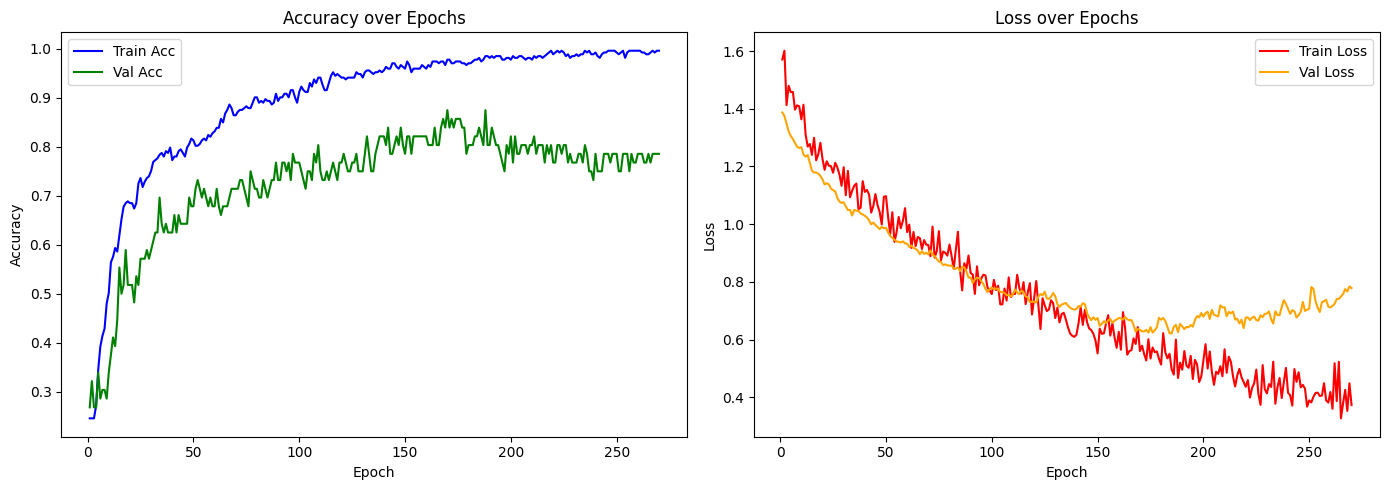

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


(270, 22, 16)
(283, 22, 16)


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
Epochs:  38%|███▊      | 383/1000 [06:48<10:58,  1.07s/it, Train Loss=0.5662, Val Loss=1.2520, Train Acc=0.9556, Val Acc=0.5893, Val Kappa=0.4356, Best Val Kappa=0.6319 (Epoch 284), Best Val Acc=0.7321 (Epoch 284)]


⏹️ Early stopping at epoch 384. No improvement for 100 consecutive epochs.
print all preds [0 1 0 3 1 3 2 2 3 3 3 2 3 3 0 1 3 1 3 3 1 3 2 3 3 3 1 3 2 3 1 2]
print all labels [3 1 0 0 2 0 2 2 3 3 3 2 3 2 2 2 2 1 1 3 1 3 2 1 2 0 1 3 2 0 2 2]
print all preds [0 1 3 1 3 3 3 0 1 3 3 0 2 2 3 3 3 1 0 1 1 0 3 3 1 0 2 1 3 1 3 0]
print all labels [0 0 0 2 2 3 1 3 1 1 3 0 1 2 3 2 3 1 1 0 1 3 2 3 2 0 2 2 3 1 3 1]
print all preds [1 2 0 3 2 1 1 2 0 0 0 1 1 0 3 0 3 1 0 0 1 1 3 3 0 2 1 1 3 3 3 3]
print all labels [1 2 0 0 3 2 2 2 2 0 0 0 0 0 0 1 2 1 0 0 1 1 0 3 0 2 2 1 3 1 1 3]
print all preds [3 1 2 1 1 3 3 0 1 3 1 1 0 0 3 0 0 1 0 3 3 1 1 0 3 3 3 0 3 3 2 3]
print all labels [2 0 2 1 0 3 1 3 1 3 0 0 3 3 1 1 2 1 1 0 2 1 1 3 0 1 3 1 3 3 2 1]
print all preds [0 3 3 3 2 3 0 1 0 3 0 1 1 0 3 2 3 3 3 3 3 0 1 1 3 1 1 0 3 1 0 2]
print all labels [0 0 3 2 2 3 0 0 0 0 0 1 1 3 0 2 0 0 3 3 3 0 0 1 3 0 0 0 2 1 3 1]
print all preds [3 1 1 0 3 0 2 1 1 1 1 1 1 3 3 3 3 3 0 3 3 3 3 1 1 1 2 1 1 3 1 1]
print all labels 

print all preds [1 0 3]
print all labels [0 1 2]

✅ Final Test Accuracy: 0.4670
📊 Final Test Cohen’s Kappa Score: 0.2926
📊 Final Test loss Score: 1.5965


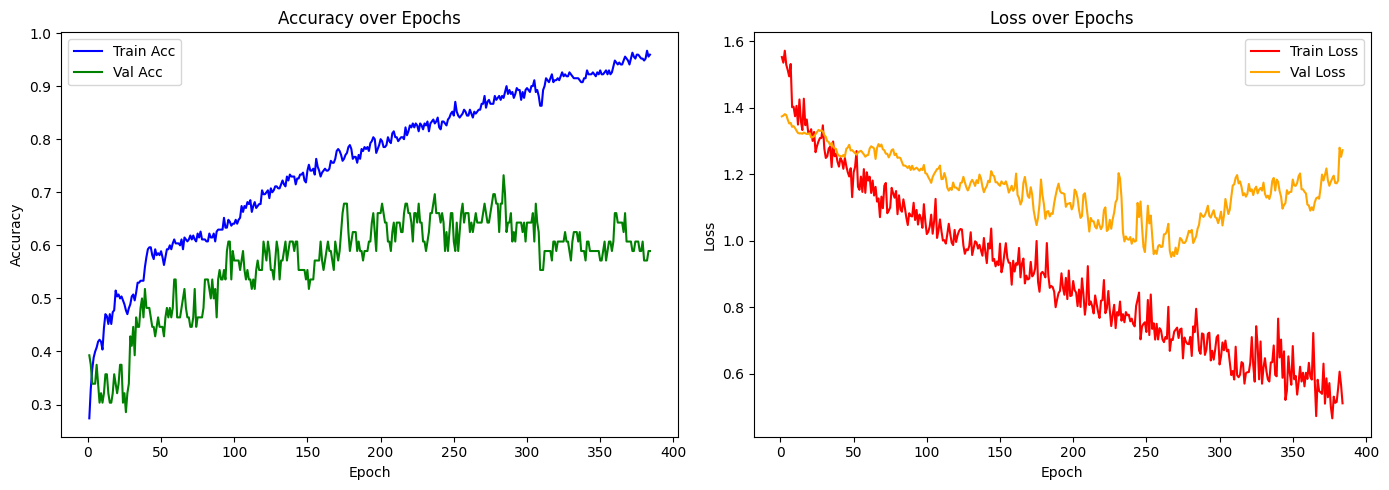

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


(270, 22, 16)
(273, 22, 16)


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
Epochs:  32%|███▏      | 322/1000 [06:16<13:13,  1.17s/it, Train Loss=0.2673, Val Loss=0.9120, Train Acc=1.0000, Val Acc=0.7222, Val Kappa=0.6295, Best Val Kappa=0.7718 (Epoch 236), Best Val Acc=0.8333 (Epoch 236)]


KeyboardInterrupt: 

In [191]:
from tqdm import trange
import numpy as np
import torch
from torch.utils.data import random_split
from torch_geometric.loader import DataLoader
from sklearn.metrics import accuracy_score, cohen_kappa_score
import matplotlib.pyplot as plt

for subi in range(0,9):
    train_data, train_label = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=True, all_trials=False)
    test_data, test_label = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=False, all_trials=False)
    tr_features, train_csp = extract_features(train_data, train_label, fs=250, n_csp_components=2)
    te_features, test_csp = extract_features(test_data, test_label, fs=250, n_csp_components=2)
    # train_features = np.concatenate(
    #     [tr_features, np.repeat(train_csp[:, np.newaxis, :], tr_features.shape[1], axis=1)],
    #     axis=-1
    # )

    # test_features = np.concatenate(
    #     [te_features, np.repeat(test_csp[:, np.newaxis, :], te_features.shape[1], axis=1)],
    #     axis=-1
    # )
    train_features = np.repeat(train_csp[:, np.newaxis, :], 22, axis=1)  # shape: (trials, channels, csp_features)
    test_features  = np.repeat(test_csp[:,  np.newaxis, :], 22, axis=1)
    print(train_features.shape)  # should be (270, 22, 33) → 17 channel features + 16 CSP features
    print(test_features.shape)   # should be (283, 22, 33)
    # train_spec_coh = compute_spectral_coherence(train_data, sfreq=250)
    # test_spec_coh  = compute_spectral_coherence(test_data, sfreq=250)

    # # Combine and save
    # spec_coh_values = np.vstack([train_spec_coh, test_spec_coh])
    # np.save("../spec_coh_values.npy", spec_coh_values)

    # print(f"Spectral coherence shape: {spec_coh_values.shape}")
    train_dataset = EEGGraphDataset(
        X=train_features, 
        y=train_label, 
        indices=np.arange(len(train_label)), 
        loader_type="train", 
        sfreq=250
    )

    test_dataset_full = EEGGraphDataset(
        X=test_features, 
        y=test_label, 
        indices=np.arange(len(test_label)), 
        loader_type="test", 
        sfreq=250
    )


    # 1. Create DataLoaders
    val_len = int(0.2 * len(test_dataset_full))
    test_len = len(test_dataset_full) - val_len
    test_dataset, val_dataset = random_split(test_dataset_full, [test_len, val_len])

    # 6. DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # 7. Model Setup
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = GraphTransformerNet(in_channels=16, hidden_channels=32, out_channels=4, K=3, transformer_heads=4)
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=5e-4)
    criterion = torch.nn.CrossEntropyLoss()

    # 8. Train Function
    def train_model(model, train_loader):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            loss = criterion(out, batch.y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(train_loader)

    # 9. Evaluate Function
    def evaluate_model(model, data_loader, return_preds=False, eval = False):
        model.eval()
        all_preds = []
        all_labels = []
        total_loss = 0
        with torch.no_grad():
            for batch in data_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
                preds = torch.argmax(out, dim=1)
                loss = criterion(out, batch.y)
                total_loss += loss.item()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(batch.y.cpu().numpy())
                if eval:
                    print('print all preds',preds.cpu().numpy())
                    print('print all labels',batch.y.cpu().numpy())

                # print('prints all labels',all_labels)
                # print('print all preds',all_preds)
        acc = accuracy_score(all_labels, all_preds)
        kappa = cohen_kappa_score(all_labels, all_preds)
        avg_loss = total_loss / len(data_loader)
        if return_preds:
            return acc, kappa, all_labels, all_preds, avg_loss
        return acc, kappa, avg_loss


    # 10. Training Loop
    num_epochs = 1000
    patience = 100
    early_stop_counter = 0

    best_val_acc = 0.0
    best_epoch = 0
    best_model_state = None
    best_val_kappa = 0.0
    train_losses = []
    train_accuracies = []
    val_accuracies = []

    epoch_bar = trange(1, num_epochs + 1, desc="Epochs", leave=True)

    val_losses = []

    for epoch in epoch_bar:
        train_loss = train_model(model, train_loader)
        train_acc, train_kappa,_ = evaluate_model(model, train_loader)
        val_acc, val_kappa, val_loss = evaluate_model(model, val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        if val_kappa > best_val_kappa:
            best_val_kappa = val_kappa
            best_epoch = epoch
            best_model_state = model.state_dict()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_model_state = model.state_dict()
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print(f"\n⏹️ Early stopping at epoch {epoch}. No improvement for {patience} consecutive epochs.")
            break

        epoch_bar.set_postfix({
            'Train Loss': f'{train_loss:.4f}',
            'Val Loss': f'{val_loss:.4f}',
            'Train Acc': f'{train_acc:.4f}',
            'Val Acc': f'{val_acc:.4f}',
            'Val Kappa': f'{val_kappa:.4f}',
            'Best Val Kappa': f'{best_val_kappa:.4f} (Epoch {best_epoch})',
            'Best Val Acc': f'{best_val_acc:.4f} (Epoch {best_epoch})'
        })


    # 11. Load Best Model & Final Test Evaluation
    if best_model_state:
        model.load_state_dict(best_model_state)

    final_acc, final_kappa, final_test_loss = evaluate_model(model, test_loader, eval=True)
    print(f"\n✅ Final Test Accuracy: {final_acc:.4f}")
    print(f"📊 Final Test Cohen’s Kappa Score: {final_kappa:.4f}")
    print(f"📊 Final Test loss Score: {final_test_loss:.4f}")

    # 12. Plot Learning Curves
    def plot_learning_curves(train_losses, val_losses, train_accuracies, val_accuracies):
        epochs = list(range(1, len(train_losses) + 1))

        plt.figure(figsize=(14, 5))

        # Accuracy Plot
        plt.subplot(1, 2, 1)
        plt.plot(epochs, train_accuracies, label='Train Acc', color='blue')
        plt.plot(epochs, val_accuracies, label='Val Acc', color='green')
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy over Epochs")
        plt.legend()

        # Loss Plot
        plt.subplot(1, 2, 2)
        plt.plot(epochs, train_losses, label='Train Loss', color='red')
        plt.plot(epochs, val_losses, label='Val Loss', color='orange')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Loss over Epochs")
        plt.legend()

        plt.tight_layout()
        plt.show()


    plot_learning_curves(train_losses, val_losses, train_accuracies, val_accuracies)


LEAVE-ONE-SUBJECT-OUT: Testing on Subject 0
Loading training data from Subject 1...


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Loading training data from Subject 2...
Loading training data from Subject 3...
Loading training data from Subject 4...
Loading training data from Subject 5...
Loading training data from Subject 6...
Loading training data from Subject 7...
Loading training data from Subject 8...
Loading test data from Subject 0...
Extracting features...
Training set shape: (2055, 22, 16) with 2055 samples
Test set shape: (281, 22, 16) with 281 samples


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/669837760.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/669837760.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])



Training model for Subject 0 as test subject...


...

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/669837760.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/669837760.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])



Training model for Subject 8 as test subject...


Epochs:  22%|██▏       | 215/1000 [11:06<40:32,  3.10s/it, Train Loss=0.7612, Val Loss=1.0186, Train Acc=0.8523, Val Acc=0.5752, Val Kappa=0.4332, Best Val Acc=0.6038 (Epoch 116)]


⏹️ Early stopping at epoch 216. No improvement for 100 consecutive epochs.
print all preds [0 1 1 0 3 0 1 1 1 1 0 2 1 0 0 1 0 0 0 2 1 0 0 1 0 1 3 0 2 0 0 1]
print all labels [0 1 1 0 1 0 1 2 1 3 0 2 1 0 3 3 3 3 0 2 1 0 0 2 3 0 2 2 2 0 0 1]
print all preds [1 0 1 1 3 1 3 1 3 3 3 3 1 2 2 1 0 0 1 1 3 1 3 0 0 3 1 1 0 0 1 0]
print all labels [1 0 1 2 2 2 3 2 2 3 3 3 3 3 2 1 0 0 1 2 3 1 2 0 0 3 1 1 0 0 2 0]
print all preds [1 3 0 1 0 3 3 1 3 0 1 0 1 2 1 2 3 2 0 3 1 0 3 2 3 1 3 0 0 0 3 1]
print all labels [1 3 3 2 0 3 3 1 3 3 1 0 1 2 2 2 3 2 0 3 1 2 1 2 3 1 2 0 0 0 3 1]
print all preds [0 3 0 2 3 2 2 0 2 1 3 1 1 0 1 1 3 2 0 2 1 0 3 1 1 2 3 3 0 1 3 1]
print all labels [0 2 0 2 3 0 2 0 2 1 3 3 2 0 3 1 3 1 0 2 1 0 2 2 0 2 3 3 0 1 3 1]
print all preds [3 1 2 3 2 3 1 0 1 1 1 3 1 1 1 1 2 3 0 2 2 3 0 1 1 3 3 0 1 0 2 1]
print all labels [3 1 1 1 2 3 0 1 0 2 2 3 0 0 1 3 3 3 1 2 1 3 3 2 1 3 3 0 1 1 2 1]
print all preds [0 0 1 1 0 3 1 2 2 0 3 2 2 2 2 0 1 0 0 0 0 2 1 2 3 0 3 0 0 2 2 2]
print all labels 


LEAVE-ONE-SUBJECT-OUT CROSS-VALIDATION RESULTS
Mean Accuracy across all subjects: 0.5032 ± 0.1089
Mean Kappa across all subjects: 0.3383 ± 0.1454

Individual Subject Results:
Subject 0: Accuracy = 0.6441, Kappa = 0.5255
Subject 1: Accuracy = 0.4417, Kappa = 0.2566
Subject 2: Accuracy = 0.5238, Kappa = 0.3651
Subject 3: Accuracy = 0.4518, Kappa = 0.2721
Subject 4: Accuracy = 0.3333, Kappa = 0.1095
Subject 5: Accuracy = 0.3860, Kappa = 0.1814
Subject 6: Accuracy = 0.5199, Kappa = 0.3633
Subject 7: Accuracy = 0.5351, Kappa = 0.3798
Subject 8: Accuracy = 0.6932, Kappa = 0.5913


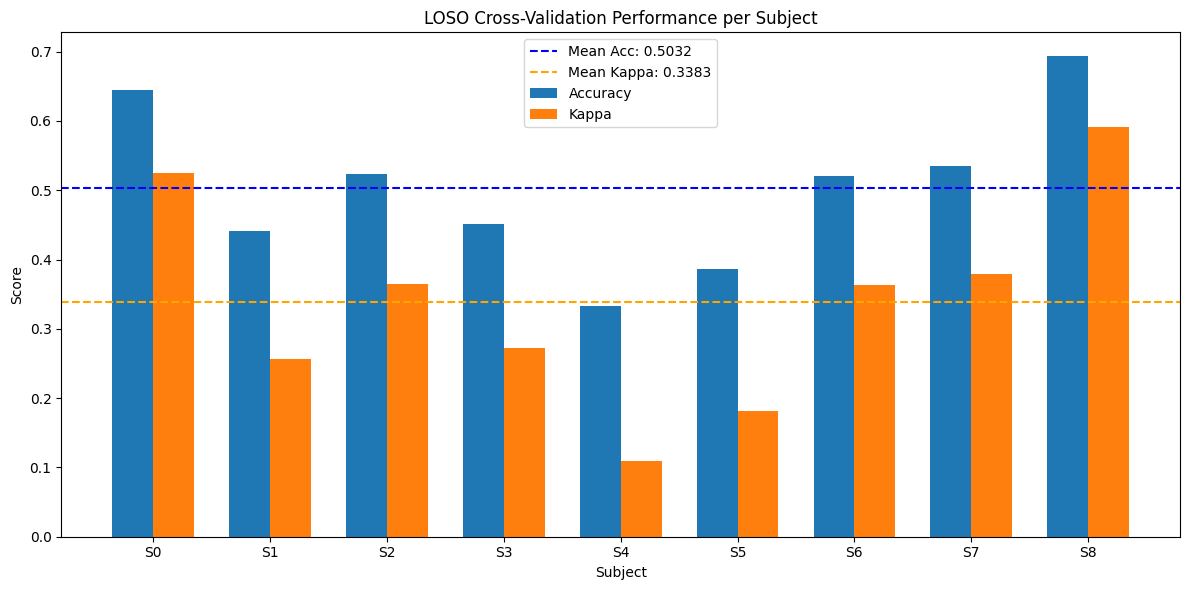

In [194]:
from tqdm import trange
import numpy as np
import torch
from torch.utils.data import random_split
from torch_geometric.loader import DataLoader
from sklearn.metrics import accuracy_score, cohen_kappa_score
import matplotlib.pyplot as plt

# Lists to store results across all subjects
all_subjects_test_acc = []
all_subjects_test_kappa = []

# Total number of subjects
total_subjects = 9

# For each iteration, leave one subject out as the test set
for test_subject_idx in range(total_subjects):
    print(f"\n{'='*50}")
    print(f"LEAVE-ONE-SUBJECT-OUT: Testing on Subject {test_subject_idx}")
    print(f"{'='*50}")
    
    # Lists to store training data from all other subjects
    all_train_data = []
    all_train_labels = []
    
    # First, collect data from all subjects except the test subject
    for train_subject_idx in range(total_subjects):
        if train_subject_idx != test_subject_idx:
            print(f"Loading training data from Subject {train_subject_idx}...")
            subj_data, subj_label = load_BCI2a_data('BCI_Kaggle/', subject=train_subject_idx, training=True, all_trials=False)
            all_train_data.append(subj_data)
            all_train_labels.append(subj_label)
    
    # Concatenate all training data
    train_data = np.concatenate(all_train_data, axis=0)
    train_label = np.concatenate(all_train_labels, axis=0)
    
    # Load test data (the left-out subject)
    print(f"Loading test data from Subject {test_subject_idx}...")
    test_data, test_label = load_BCI2a_data('BCI_Kaggle/', subject=test_subject_idx, training=False, all_trials=False)
    
    # Feature extraction
    print("Extracting features...")
    tr_features, train_csp = extract_features(train_data, train_label, fs=250, n_csp_components=2)
    te_features, test_csp = extract_features(test_data, test_label, fs=250, n_csp_components=2)
    
    # Prepare features for the graph network
    train_features = np.repeat(train_csp[:, np.newaxis, :], 22, axis=1)  # shape: (trials, channels, csp_features)
    test_features = np.repeat(test_csp[:, np.newaxis, :], 22, axis=1)
    
    print(f"Training set shape: {train_features.shape} with {len(train_label)} samples")
    print(f"Test set shape: {test_features.shape} with {len(test_label)} samples")
    
    # Create datasets
    train_dataset = EEGGraphDataset(
        X=train_features, 
        y=train_label, 
        indices=np.arange(len(train_label)), 
        loader_type="train", 
        sfreq=250
    )
    
    # For validation, we'll take a portion of the training set
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])
    
    test_dataset = EEGGraphDataset(
        X=test_features, 
        y=test_label, 
        indices=np.arange(len(test_label)), 
        loader_type="test", 
        sfreq=250
    )
    
    # Create DataLoaders
    train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    # Model Setup
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = GraphTransformerNet(in_channels=16, hidden_channels=32, out_channels=4, K=3, transformer_heads=4)
    model.to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=5e-4)
    criterion = torch.nn.CrossEntropyLoss()
    
    # Train Function
    def train_model(model, train_loader):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            loss = criterion(out, batch.y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(train_loader)
    
    # Evaluate Function
    def evaluate_model(model, data_loader, return_preds=False, eval=False):
        model.eval()
        all_preds = []
        all_labels = []
        total_loss = 0
        with torch.no_grad():
            for batch in data_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
                preds = torch.argmax(out, dim=1)
                loss = criterion(out, batch.y)
                total_loss += loss.item()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(batch.y.cpu().numpy())
                if eval:
                    print('print all preds', preds.cpu().numpy())
                    print('print all labels', batch.y.cpu().numpy())
        
        acc = accuracy_score(all_labels, all_preds)
        kappa = cohen_kappa_score(all_labels, all_preds)
        avg_loss = total_loss / len(data_loader)
        if return_preds:
            return acc, kappa, all_labels, all_preds, avg_loss
        return acc, kappa, avg_loss
    
    # Training Loop
    num_epochs = 1000
    patience = 100
    early_stop_counter = 0
    
    best_val_acc = 0.0
    best_epoch = 0
    best_model_state = None
    best_val_kappa = 0.0
    train_losses = []
    train_accuracies = []
    val_accuracies = []
    val_losses = []
    
    print(f"\nTraining model for Subject {test_subject_idx} as test subject...")
    epoch_bar = trange(1, num_epochs + 1, desc="Epochs", leave=True)
    
    for epoch in epoch_bar:
        train_loss = train_model(model, train_loader)
        train_acc, train_kappa, _ = evaluate_model(model, train_loader)
        val_acc, val_kappa, val_loss = evaluate_model(model, val_loader)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        
        if val_kappa > best_val_kappa:
            best_val_kappa = val_kappa
            best_epoch = epoch
            best_model_state = model.state_dict()
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_model_state = model.state_dict()
            early_stop_counter = 0
        else:
            early_stop_counter += 1
        
        if early_stop_counter >= patience:
            print(f"\n⏹️ Early stopping at epoch {epoch}. No improvement for {patience} consecutive epochs.")
            break
        
        epoch_bar.set_postfix({
            'Train Loss': f'{train_loss:.4f}',
            'Val Loss': f'{val_loss:.4f}',
            'Train Acc': f'{train_acc:.4f}',
            'Val Acc': f'{val_acc:.4f}',
            'Val Kappa': f'{val_kappa:.4f}',
            'Best Val Acc': f'{best_val_acc:.4f} (Epoch {best_epoch})'
        })
    
    # Load Best Model & Final Test Evaluation
    if best_model_state:
        model.load_state_dict(best_model_state)
    
    final_acc, final_kappa, final_test_loss = evaluate_model(model, test_loader, eval=True)
    print(f"\n✅ Final Test Accuracy for Subject {test_subject_idx}: {final_acc:.4f}")
    print(f"📊 Final Test Cohen's Kappa Score: {final_kappa:.4f}")
    print(f"📊 Final Test Loss Score: {final_test_loss:.4f}")
    
    # Store results
    all_subjects_test_acc.append(final_acc)
    all_subjects_test_kappa.append(final_kappa)
    
    # Plot Learning Curves
    plt.figure(figsize=(14, 5))
    
    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label='Train Acc', color='blue')
    plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, label='Val Acc', color='green')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy over Epochs (Subject {test_subject_idx} as Test)")
    plt.legend()
    
    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss', color='red')
    plt.plot(range(1, len(val_losses) + 1), val_losses, label='Val Loss', color='orange')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss over Epochs (Subject {test_subject_idx} as Test)")
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(f"loso_subject_{test_subject_idx}_learning_curves.png")
    plt.close()

# After all iterations, calculate and print average performance
mean_acc = np.mean(all_subjects_test_acc)
std_acc = np.std(all_subjects_test_acc)
mean_kappa = np.mean(all_subjects_test_kappa)
std_kappa = np.std(all_subjects_test_kappa)

print("\n" + "="*50)
print("LEAVE-ONE-SUBJECT-OUT CROSS-VALIDATION RESULTS")
print("="*50)
print(f"Mean Accuracy across all subjects: {mean_acc:.4f} ± {std_acc:.4f}")
print(f"Mean Kappa across all subjects: {mean_kappa:.4f} ± {std_kappa:.4f}")
print("\nIndividual Subject Results:")
for i, (acc, kappa) in enumerate(zip(all_subjects_test_acc, all_subjects_test_kappa)):
    print(f"Subject {i}: Accuracy = {acc:.4f}, Kappa = {kappa:.4f}")

# Plot overall performance
plt.figure(figsize=(12, 6))
subjects = list(range(total_subjects))
width = 0.35

plt.bar(subjects, all_subjects_test_acc, width, label='Accuracy')
plt.bar([x + width for x in subjects], all_subjects_test_kappa, width, label='Kappa')

plt.xlabel('Subject')
plt.ylabel('Score')
plt.title('LOSO Cross-Validation Performance per Subject')
plt.xticks([x + width/2 for x in subjects], [f'S{i}' for i in subjects])
plt.legend()

plt.axhline(y=mean_acc, color='blue', linestyle='--', label=f'Mean Acc: {mean_acc:.4f}')
plt.axhline(y=mean_kappa, color='orange', linestyle='--', label=f'Mean Kappa: {mean_kappa:.4f}')
plt.legend()

plt.tight_layout()
plt.savefig("loso_overall_performance.png")
plt.show()

In [175]:
from tqdm import trange
import numpy as np
import torch
from torch.utils.data import random_split
from torch_geometric.loader import DataLoader
from sklearn.metrics import accuracy_score, cohen_kappa_score
import matplotlib.pyplot as plt

for subi in range(1, 10):
    # 1. Load Data
    train_data, train_label = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=True, all_trials=True)
    test_data, test_label = load_BCI2a_data('BCI_Kaggle/', subject=subi, training=False, all_trials=True)
    train_features = channelwise_csp(train_data, train_label)
    test_features = channelwise_csp(test_data, test_label)


    train_spec_coh = compute_spectral_coherence(train_data, sfreq=250)  # shape: [samples, channels, channels]
    test_spec_coh = compute_spectral_coherence(test_data, sfreq=250)

    train_dataset = EEGGraphDataset_2(
        X=train_features,
        y=train_label,
        indices=np.arange(len(train_label)),
        loader_type="train",
        sfreq=250,
        spec_coh_matrix=train_spec_coh
    )

    test_dataset_full = EEGGraphDataset_2(
        X=test_features,
        y=test_label,
        indices=np.arange(len(test_label)),
        loader_type="test",
        sfreq=250,
        spec_coh_matrix=test_spec_coh
)

    # 5. Create Validation Split (20% of test set)
    val_len = int(0.2 * len(test_dataset_full))
    test_len = len(test_dataset_full) - val_len
    test_dataset, val_dataset = random_split(test_dataset_full, [test_len, val_len])

    # 6. DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

    # 7. Model Setup
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = GraphTransformerNet(in_channels=1, hidden_channels=32, out_channels=4, K=3, transformer_heads=4)
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=5e-4)
    criterion = torch.nn.CrossEntropyLoss()

    # 8. Train Function
    def train_model(model, train_loader):
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            loss = criterion(out, batch.y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(train_loader)

    # 9. Evaluate Function
    def evaluate_model(model, data_loader, return_preds=False, eval = False):
        model.eval()
        all_preds = []
        all_labels = []
        total_loss = 0
        with torch.no_grad():
            for batch in data_loader:
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
                preds = torch.argmax(out, dim=1)
                loss = criterion(out, batch.y)
                total_loss += loss.item()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(batch.y.cpu().numpy())
                if eval:
                    print('print all preds',preds.cpu().numpy())
                    print('print all labels',batch.y.cpu().numpy())

                # print('prints all labels',all_labels)
                # print('print all preds',all_preds)
        acc = accuracy_score(all_labels, all_preds)
        kappa = cohen_kappa_score(all_labels, all_preds)
        avg_loss = total_loss / len(data_loader)
        if return_preds:
            return acc, kappa, all_labels, all_preds, avg_loss
        return acc, kappa, avg_loss


    # 10. Training Loop
    num_epochs = 1000
    patience = 100
    early_stop_counter = 0

    best_val_acc = 0.0
    best_epoch = 0
    best_model_state = None
    best_val_kappa = 0.0
    train_losses = []
    train_accuracies = []
    val_accuracies = []

    epoch_bar = trange(1, num_epochs + 1, desc="Epochs", leave=True)

    val_losses = []

    for epoch in epoch_bar:
        train_loss = train_model(model, train_loader)
        train_acc, train_kappa,_ = evaluate_model(model, train_loader)
        val_acc, val_kappa, val_loss = evaluate_model(model, val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        if val_kappa > best_val_kappa:
            best_val_kappa = val_kappa
            best_epoch = epoch
            best_model_state = model.state_dict()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_model_state = model.state_dict()
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print(f"\n⏹️ Early stopping at epoch {epoch}. No improvement for {patience} consecutive epochs.")
            break

        epoch_bar.set_postfix({
            'Train Loss': f'{train_loss:.4f}',
            'Val Loss': f'{val_loss:.4f}',
            'Train Acc': f'{train_acc:.4f}',
            'Val Acc': f'{val_acc:.4f}',
            'Val Kappa': f'{val_kappa:.4f}',
            'Best Val Kappa': f'{best_val_kappa:.4f} (Epoch {best_epoch})',
            'Best Val Acc': f'{best_val_acc:.4f} (Epoch {best_epoch})'
        })


    # 11. Load Best Model & Final Test Evaluation
    if best_model_state:
        model.load_state_dict(best_model_state)

    final_acc, final_kappa, final_test_loss = evaluate_model(model, test_loader, eval=True)
    print(f"\n✅ Final Test Accuracy: {final_acc:.4f}")
    print(f"📊 Final Test Cohen’s Kappa Score: {final_kappa:.4f}")
    print(f"📊 Final Test loss Score: {final_test_loss:.4f}")

    # 12. Plot Learning Curves
    def plot_learning_curves(train_losses, val_losses, train_accuracies, val_accuracies):
        epochs = list(range(1, len(train_losses) + 1))

        plt.figure(figsize=(14, 5))

        # Accuracy Plot
        plt.subplot(1, 2, 1)
        plt.plot(epochs, train_accuracies, label='Train Acc', color='blue')
        plt.plot(epochs, val_accuracies, label='Val Acc', color='green')
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy over Epochs")
        plt.legend()

        # Loss Plot
        plt.subplot(1, 2, 2)
        plt.plot(epochs, train_losses, label='Train Loss', color='red')
        plt.plot(epochs, val_losses, label='Val Loss', color='orange')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Loss over Epochs")
        plt.legend()

        plt.tight_layout()
        plt.show()


    plot_learning_curves(train_losses, val_losses, train_accuracies, val_accuracies)


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


Computing rank from data with rank=None
    Using tolerance 0.63 (2.2e-16 eps * 1 dim * 2.8e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.56 (2.2e-16 eps * 1 dim * 2.5e+15  max singular value)
    Estimated rank (data): 1
    data: rank 1 computed from 1 data channel with 0 projectors
Reducing data rank from 1 -> 1
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.62 (2.2e-16 eps * 1 dim * 2.8e+15  max s

Computing coherence: 100%|██████████| 288/288 [00:20<00:00, 13.98it/s]
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1945304688.py:50: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1945304688.py:50: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [176]:
tr_features, train_csp = extract_features(train_data, train_label, fs=250, n_csp_components=2)
te_features, test_csp = extract_features(test_data, test_label, fs=250, n_csp_components=2)
train_features = np.repeat(train_csp[:, np.newaxis, :], 22, axis=1)  # shape: (trials, channels, csp_features)
test_features  = np.repeat(test_csp[:,  np.newaxis, :], 22, axis=1)

Not setting metadata
288 matching events found


No baseline correction applied
0 projection items activated
Computing rank from data with rank=None
    Using tolerance 58 (2.2e-16 eps * 22 dim * 1.2e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.


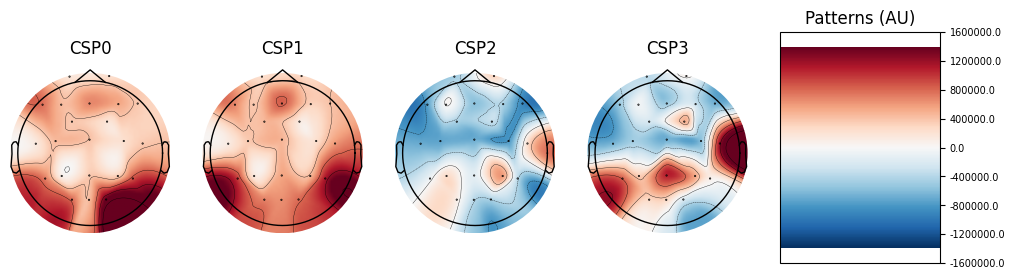

<Figure size 640x480 with 0 Axes>

In [179]:
import numpy as np
import mne
from mne.decoding import CSP
import matplotlib.pyplot as plt
sfreq = 250  # Set your sampling frequency (Hz), change if different
channel_names = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 
                 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 
                 'Fz', 'Cz', 'Pz', 'Oz', 'FC1', 'FC2']  # Example

info = mne.create_info(ch_names=channel_names, sfreq=sfreq, ch_types='eeg')
info.set_montage('standard_1020')

# Step 2: Convert to EpochsArray
epochs = mne.EpochsArray(train_data, info)
epochs.set_montage('standard_1020')

# Step 3: Apply CSP
labels = train_label.astype(int)  # Ensure labels are int
csp = CSP(n_components=4, log=None)
csp.fit(epochs.get_data(), labels)

# Step 4: Plot topographic maps of CSP spatial patterns
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
csp.plot_patterns(epochs.info, ch_type='eeg', units='Patterns (AU)', axes=axes, colorbar=True)
plt.suptitle('Topographic Maps of CSP Filters (Spatial Patterns)', fontsize=14)
plt.tight_layout()
plt.show()

In [158]:
train_data, train_label = load_BCI2a_data('BCI_Kaggle/', subject=3, training=True, all_trials=True)
test_data, test_label = load_BCI2a_data('BCI_Kaggle/', subject=3, training=False, all_trials=True)

# 2. Extract CSP Features
# train_csp = per_channel_csp_features(train_data, train_label, n_csp=2)
# test_csp = per_channel_csp_features(test_data, test_label, n_csp=2)
# tr_features, _ = extract_features(train_data, train_label, fs=250, n_csp_components=2)
# te_features, _ = extract_features(test_data, test_label, fs=250, n_csp_components=2)


train_csp_filters = compute_csp_filters(train_data, train_label, n_classes=4, m=2)
test_csp_filters = compute_csp_filters(test_data, test_label, n_classes=4, m=2)

train_features = per_channel_csp_features(train_data,csp_filters)
test_features = per_channel_csp_features(test_data,csp_filters)

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/1087658332.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


In [137]:
train_csp.shape

(288, 22, 8)

In [121]:
tr_features.shape

(288, 22, 17)

In [122]:
combined_features = np.concatenate([train_csp, tr_features], axis=-1)

In [159]:
# train_features = np.concatenate([train_csp,tr_features], axis=-1)
# test_features = np.concatenate([test_csp,te_features], axis=-1)
# train_features = train_csp
# test_features = test_csp
# print(train_features.shape)
# print(test_features.shape)

# 3. Compute Spectral Coherence
# train_spec_coh = compute_spectral_coherence(train_data, sfreq=250)
# test_spec_coh = compute_spectral_coherence(test_data, sfreq=250)

# spec_coh_values = np.vstack([train_spec_coh, test_spec_coh])
# np.save("../spec_coh_values.npy", spec_coh_values)
# print(f"Spectral coherence shape: {spec_coh_values.shape}")

# 4. Create Datasets
train_dataset = EEGGraphDataset(
    X=train_features,
    y=train_label,
    indices=np.arange(len(train_label)),
    loader_type="train",
    sfreq=250
)

test_dataset_full = EEGGraphDataset(
    X=test_features,
    y=test_label,
    indices=np.arange(len(test_label)),
    loader_type="test",
    sfreq=250
)

# 5. Create Validation Split (20% of test set)
val_len = int(0.2 * len(test_dataset_full))
test_len = len(test_dataset_full) - val_len
test_dataset, val_dataset = random_split(test_dataset_full, [test_len, val_len])

# 6. DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_23176/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])


In [160]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GraphTransformerNet(in_channels=8, hidden_channels=32, out_channels=4, K=3, transformer_heads=4)
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

# 8. Train Function
def train_model(model, train_loader):
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

# 9. Evaluate Function
def evaluate_model(model, data_loader, return_preds=False, eval = False):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0
    with torch.no_grad():
        for batch in data_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            preds = torch.argmax(out, dim=1)
            loss = criterion(out, batch.y)
            total_loss += loss.item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch.y.cpu().numpy())
            if eval:
                print('print all preds',preds.cpu().numpy())
                print('print all labels',batch.y.cpu().numpy())

            # print('prints all labels',all_labels)
            # print('print all preds',all_preds)
    acc = accuracy_score(all_labels, all_preds)
    kappa = cohen_kappa_score(all_labels, all_preds)
    avg_loss = total_loss / len(data_loader)
    if return_preds:
        return acc, kappa, all_labels, all_preds, avg_loss
    return acc, kappa, avg_loss


# 10. Training Loop
num_epochs = 1000
patience = 100
early_stop_counter = 0

best_val_acc = 0.0
best_epoch = 0
best_model_state = None
best_val_kappa = 0.0
train_losses = []
train_accuracies = []
val_accuracies = []

epoch_bar = trange(1, num_epochs + 1, desc="Epochs", leave=True)

val_losses = []

for epoch in epoch_bar:
    train_loss = train_model(model, train_loader)
    train_acc, train_kappa,_ = evaluate_model(model, train_loader)
    val_acc, val_kappa, val_loss = evaluate_model(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    if val_kappa > best_val_kappa:
        best_val_kappa = val_kappa
        best_epoch = epoch
        best_model_state = model.state_dict()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        best_model_state = model.state_dict()
        early_stop_counter = 0
    else:
        early_stop_counter += 1

    if early_stop_counter >= patience:
        print(f"\n⏹️ Early stopping at epoch {epoch}. No improvement for {patience} consecutive epochs.")
        break

    epoch_bar.set_postfix({
        'Train Loss': f'{train_loss:.4f}',
        'Val Loss': f'{val_loss:.4f}',
        'Train Acc': f'{train_acc:.4f}',
        'Val Acc': f'{val_acc:.4f}',
        'Val Kappa': f'{val_kappa:.4f}',
        'Best Val Kappa': f'{best_val_kappa:.4f} (Epoch {best_epoch})',
        'Best Val Acc': f'{best_val_acc:.4f} (Epoch {best_epoch})'
    })


# 11. Load Best Model & Final Test Evaluation
if best_model_state:
    model.load_state_dict(best_model_state)

final_acc, final_kappa, final_test_loss = evaluate_model(model, test_loader, eval=True)
print(f"\n✅ Final Test Accuracy: {final_acc:.4f}")
print(f"📊 Final Test Cohen’s Kappa Score: {final_kappa:.4f}")
print(f"📊 Final Test loss Score: {final_test_loss:.4f}")

# 12. Plot Learning Curves
def plot_learning_curves(train_losses, val_losses, train_accuracies, val_accuracies):
    epochs = list(range(1, len(train_losses) + 1))

    plt.figure(figsize=(14, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_accuracies, label='Train Acc', color='blue')
    plt.plot(epochs, val_accuracies, label='Val Acc', color='green')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy over Epochs")
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_losses, label='Train Loss', color='red')
    plt.plot(epochs, val_losses, label='Val Loss', color='orange')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss over Epochs")
    plt.legend()

    plt.tight_layout()
    plt.show()


plot_learning_curves(train_losses, val_losses, train_accuracies, val_accuracies)


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epochs:  14%|█▍        | 145/1000 [02:15<13:21,  1.07it/s, Train Loss=0.8968, Val Loss=1.1087, Train Acc=0.7639, Val Acc=0.4912, Val Kappa=0.3308, Best Val Kappa=0.4325 (Epoch 89), Best Val Acc=0.5614 (Epoch 89)]


KeyboardInterrupt: 

In [38]:
import numpy as np
import pywt
from tqdm import tqdm

def compute_cwt(signal, wavelet='morl', scales=None, num_freqs=32):
    if scales is None:
        scales = np.arange(1, num_freqs + 1)
    coefficients, _ = pywt.cwt(signal, scales, wavelet)
    return np.abs(coefficients)

def create_cwt_tensor(X, wavelet='morl', num_freqs=32):
    """
    X: ndarray of shape (samples, channels, timepoints)
    Returns: ndarray of shape (samples, num_freqs, timepoints, channels)
    """
    num_samples, num_channels, num_timepoints = X.shape
    cwt_output = np.zeros((num_samples, num_freqs, num_timepoints, num_channels), dtype=np.float32)

    for sample_idx in tqdm(range(num_samples), desc="Generating CWT features"):
        for ch_idx in range(num_channels):
            signal = X[sample_idx, ch_idx]  # (timepoints,)
            cwt_result = compute_cwt(signal, wavelet=wavelet, num_freqs=num_freqs)  # (num_freqs, timepoints)
            cwt_output[sample_idx, :, :, ch_idx] = cwt_result

    return cwt_output


In [39]:
X_train_cwt = create_cwt_tensor(train_data, wavelet='morl', num_freqs=32)  # → shape: (288, 32, 1000, 22)

Generating CWT features: 100%|██████████| 262/262 [00:31<00:00,  8.44it/s]


In [40]:
X_test_cwt = create_cwt_tensor(test_data, wavelet='morl', num_freqs=32)  # → shape: (283, 32, 1000, 22)

Generating CWT features: 100%|██████████| 228/228 [00:24<00:00,  9.18it/s]


In [41]:
# Normalize across time and frequencies
X_train_cwt -= X_train_cwt.mean(axis=(1, 2), keepdims=True)
X_train_cwt /= (X_train_cwt.std(axis=(1, 2), keepdims=True) + 1e-8)

In [53]:
import torch
import numpy as np
import pandas as pd
from torch_geometric.data import Data, Dataset
from itertools import product
import math

class EEGGraphDataset(Dataset):
    def __init__(self, X, y, indices, loader_type, sfreq, transform=None):
        self.epochs = X
        self.labels = y
        self.indices = indices
        self.sfreq = sfreq
        self.loader_type = loader_type
        self.transform = transform

        # Your updated EEG channel names
        self.ch_names = [
            'Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4',
            'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6',
            'CP3', 'CP1', 'CPz', 'CP2', 'CP4',
            'P1', 'Pz', 'P2', 'POz'
        ]

        self.node_ids = range(len(self.ch_names))

        # Create fully connected undirected graph (or change this to a sparse graph if needed)
        self.edge_index = torch.tensor(
            [[a, b] for a, b in product(self.node_ids, self.node_ids)],
            dtype=torch.long
        ).t().contiguous()

        # Compute and normalize geodesic distances
        self.distances = self.get_sensor_distances()
        a = np.array(self.distances)
        self.distances = ((a - np.min(a)) / (np.max(a) - np.min(a))).astype(np.float32)

        # Load any edge-wise spectral coherence features (shape: [samples, edges])
        self.spec_coh_values = np.load("../spec_coh_values.npy", allow_pickle=True)

    def get_sensor_distances(self):
        coords_1010 = pd.read_csv("standard_1010.tsv.txt", sep='\t')
        distances = []
        for edge_idx in range(self.edge_index.shape[1]):
            i = self.edge_index[0, edge_idx]
            j = self.edge_index[1, edge_idx]
            dist = self.get_geodesic_distance(self.ch_names[i], self.ch_names[j], coords_1010)
            distances.append(dist)
        return distances

    def get_geodesic_distance(self, ch1, ch2, coords_1010):
        # Find 3D coords from standard_1010.tsv.txt
        def get_coords(ch):
            row = coords_1010[coords_1010['label'] == ch]
            if row.empty:
                raise ValueError(f"Channel {ch} not found in 10-10 coordinates!")
            return float(row['x']), float(row['y']), float(row['z'])

        x1, y1, z1 = get_coords(ch1)
        x2, y2, z2 = get_coords(ch2)

        dot_product = x1 * x2 + y1 * y2 + z1 * z2
        dot_product = max(min(dot_product, 1.0), -1.0)  # Clamp for stability
        return math.acos(dot_product)  # r = 1

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        idx = self.indices[idx]
        raw_sample = self.epochs[idx]  # (32, 1000, 22)
        raw_sample = np.transpose(raw_sample, (2, 0, 1))  # → (22, 32, 1000)

        # Pool over time to get (22, 32) feature matrix
        node_features = torch.tensor(raw_sample.mean(axis=2), dtype=torch.float32)  # → (22, 32)

        # Edge weights (based on geodesic distances)
        edge_weights = torch.tensor(self.distances, dtype=torch.float32).clone().detach()

        return Data(
            x=node_features,
            edge_index=self.edge_index,
            edge_attr=edge_weights,
            dataset_idx=idx,
            y=torch.tensor(self.labels[idx], dtype=torch.long)
        )

    


In [54]:
train_dataset = EEGGraphDataset(
    X=X_train_cwt, 
    y=train_label, 
    indices=np.arange(len(train_label)), 
    loader_type="train", 
    sfreq=250
)

test_dataset = EEGGraphDataset(
    X=X_test_cwt, 
    y=test_label, 
    indices=np.arange(len(test_label)), 
    loader_type="test", 
    sfreq=250
)

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_58313/4014561317.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_58313/4014561317.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])


In [55]:
train_dataset[0].x.shape

torch.Size([22, 32])

Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epochs:  15%|█▍        | 146/1000 [04:08<24:10,  1.70s/it, Train Loss=1.2624, Train Acc=0.5267, Test Acc=0.2588, Best Test Acc=0.2763 (Epoch 47)]


⏹️ Early stopping at epoch 147. No improvement for 100 consecutive epochs.

✅ Training Complete! Best Test Accuracy: 0.2763 at Epoch 47


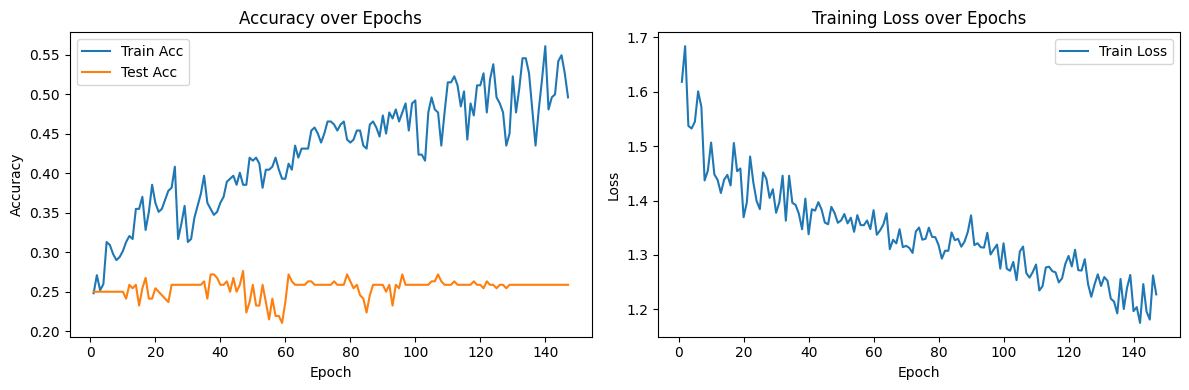

In [57]:
import torch
from torch_geometric.loader import DataLoader
from sklearn.metrics import accuracy_score
from tqdm import tqdm, trange
import matplotlib.pyplot as plt

# 1. Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 2. Instantiate Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GCN(in_channels=32, hidden_channels=20, out_channels=4, K=2)

# 3. Define optimizer and loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

# 4. Train Function
def train_model(model, train_loader):
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

# 5. Evaluate Function
def evaluate_model(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in data_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            preds = torch.argmax(out, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch.y.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    return acc

# 6. Training Loop with Progress Bar and Metrics Logging
# 6. Training Loop with Early Stopping and Progress Bar
num_epochs = 1000
patience = 100
early_stop_counter = 0

best_test_acc = 0.0
best_epoch = 0
best_model_state = None

train_losses = []
train_accuracies = []
test_accuracies = []

epoch_bar = trange(1, num_epochs + 1, desc="Epochs", leave=True)

for epoch in epoch_bar:
    train_loss = train_model(model, train_loader)
    train_acc = evaluate_model(model, train_loader)
    test_acc = evaluate_model(model, test_loader)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    # Check for improvement
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_epoch = epoch
        best_model_state = model.state_dict()  # Save best model
        early_stop_counter = 0
    else:
        early_stop_counter += 1

    # Early stopping condition
    if early_stop_counter >= patience:
        print(f"\n⏹️ Early stopping at epoch {epoch}. No improvement for {patience} consecutive epochs.")
        break

    epoch_bar.set_postfix({
        'Train Loss': f'{train_loss:.4f}',
        'Train Acc': f'{train_acc:.4f}',
        'Test Acc': f'{test_acc:.4f}',
        'Best Test Acc': f'{best_test_acc:.4f} (Epoch {best_epoch})'
    })

# Load the best model state before evaluation
if best_model_state:
    model.load_state_dict(best_model_state)

print(f"\n✅ Training Complete! Best Test Accuracy: {best_test_acc:.4f} at Epoch {best_epoch}")


# 7. Optional: Plot Learning Curves
def plot_learning_curves(train_losses, train_accuracies, test_accuracies):
    epochs = list(range(1, len(train_losses) + 1))

    plt.figure(figsize=(12, 4))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_accuracies, label='Train Acc')
    plt.plot(epochs, test_accuracies, label='Test Acc')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy over Epochs")
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss over Epochs")
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call the plotting function
plot_learning_curves(train_losses, train_accuracies, test_accuracies)

In [48]:
train_dataset[0].x.shape

torch.Size([22, 1])

In [59]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool, BatchNorm, global_add_pool


class EEGGraphConvNet(nn.Module):
    def __init__(self, reduced_sensors, sfreq=None, batch_size=32):
        super(EEGGraphConvNet, self).__init__()
		
		# need these for train_model_and_visualize() function
        self.sfreq = sfreq
        self.batch_size = batch_size
        self.input_size = 8 if reduced_sensors else 62

        self.conv1 = GCNConv(32, 34, improved=True, cached=True, normalize=False)
        self.conv2 = GCNConv(34, 68, improved=True, cached=True, normalize=False)
        self.conv3 = GCNConv(68, 128, improved=True, cached=True, normalize=False)
        self.conv4 = GCNConv(128,256, improved=True, cached=True, normalize=False)
        self.conv4_bn = BatchNorm(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

        self.fc_block1 = nn.Linear(256, 100)
        self.fc_block2 = nn.Linear(100, 25)
        self.fc_block3 = nn.Linear(25, 4)

        # Xavier initializations  #init gcn layers
        self.fc_block1.apply(lambda x: nn.init.xavier_normal_(x.weight, gain=1) if type(x) == nn.Linear else None)
        self.fc_block2.apply(lambda x: nn.init.xavier_normal_(x.weight, gain=1) if type(x) == nn.Linear else None)
        self.fc_block3.apply(lambda x: nn.init.xavier_normal_(x.weight, gain=1) if type(x) == nn.Linear else None)
    
    def forward(self, x, edge_index, edge_weight, batch, return_graph_embedding=False):
        x = F.leaky_relu(self.conv1(x, edge_index, edge_weight))

        x = F.leaky_relu(self.conv2(x, edge_index, edge_weight))

        x = F.leaky_relu(self.conv3(x, edge_index, edge_weight))
        x = F.leaky_relu(self.conv4_bn(self.conv4(x, edge_index, edge_weight)))
        out = global_add_pool(x, batch=batch)
        if return_graph_embedding:
            return out

        out = F.leaky_relu(self.fc_block1(out), negative_slope=0.01)
        out = F.dropout(out, p = 0.2, training=self.training)
        out = F.leaky_relu(self.fc_block2(out), negative_slope=0.01)
        out = self.fc_block3(out)

        return out

Epochs: 100%|██████████| 500/500 [17:52<00:00,  2.15s/it, Train Loss=0.4560, Train Acc=0.8969, Test Acc=0.2588, Best Test Acc=0.3114 (Epoch 196)]



✅ Training Complete! Best Test Accuracy: 0.3114 at Epoch 196


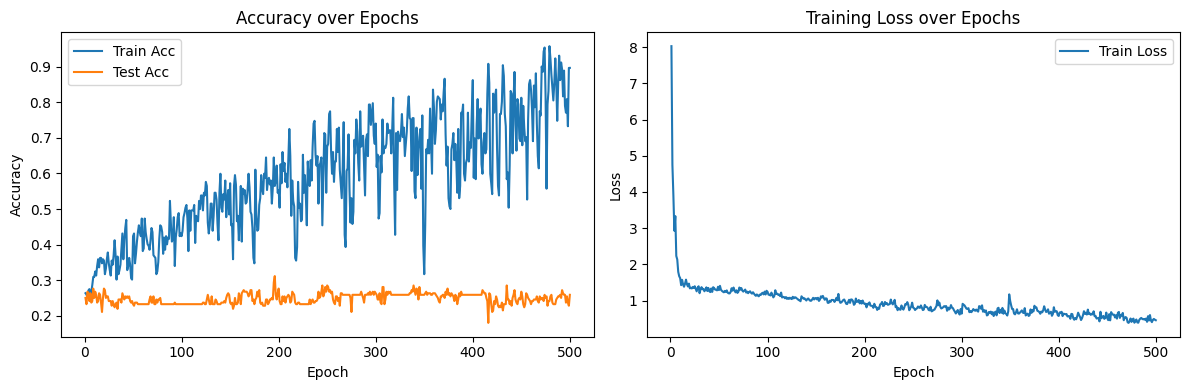

In [60]:
import torch
from torch_geometric.loader import DataLoader
from sklearn.metrics import accuracy_score
from tqdm import tqdm, trange
import matplotlib.pyplot as plt

# 1. Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 2. Instantiate Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = EEGGraphConvNet(reduced_sensors=False, sfreq=250).to(device)

# 3. Define optimizer and loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

# 4. Train Function
def train_model(model, train_loader):
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

# 5. Evaluate Function
def evaluate_model(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in data_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            preds = torch.argmax(out, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch.y.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    return acc

# 6. Training Loop with Progress Bar and Metrics Logging
num_epochs = 500
best_test_acc = 0.0
best_epoch = 0

train_losses = []
train_accuracies = []
test_accuracies = []

epoch_bar = trange(1, num_epochs + 1, desc="Epochs", leave=True)

for epoch in epoch_bar:
    train_loss = train_model(model, train_loader)
    train_acc = evaluate_model(model, train_loader)
    test_acc = evaluate_model(model, test_loader)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_epoch = epoch

    epoch_bar.set_postfix({
        'Train Loss': f'{train_loss:.4f}',
        'Train Acc': f'{train_acc:.4f}',
        'Test Acc': f'{test_acc:.4f}',
        'Best Test Acc': f'{best_test_acc:.4f} (Epoch {best_epoch})'
    })

print(f"\n✅ Training Complete! Best Test Accuracy: {best_test_acc:.4f} at Epoch {best_epoch}")

# 7. Optional: Plot Learning Curves
def plot_learning_curves(train_losses, train_accuracies, test_accuracies):
    epochs = list(range(1, len(train_losses) + 1))

    plt.figure(figsize=(12, 4))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_accuracies, label='Train Acc')
    plt.plot(epochs, test_accuracies, label='Test Acc')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy over Epochs")
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss over Epochs")
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call the plotting function
plot_learning_curves(train_losses, train_accuracies, test_accuracies)